<a href="https://colab.research.google.com/github/guilhermek32/ListaDataScience-2026.1/blob/main/Lista_1_Antonio_Guilherme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aluno: Antonio Guilherme da Silva

Nome da base: Medical Appointment No Shows.csv

In [ ]:
!git clone "https://github.com/guilhermek32/ListaDataScience-2026.1.git"
# Entra na pasta clonada
%cd ListaDataScience-2026.1

c:\Users\guilh\Documents\code\cd\ListaDataScience-2026.1\ListaDataScience-2026.1
c:\Users\guilh\Documents\code\cd\ListaDataScience-2026.1


Cloning into 'ListaDataScience-2026.1'...


1.

Faça um código em Python que carregue a base escolhida e gere um diagnóstico
inicial automatizado. Mostre dimensões da base, tipos de dados, valores ausentes,
duplicidades, cardinalidade das colunas e possíveis inconsistências de leitura. Em
seguida, defina qual será o problema computacional tratado no cenário escolhido,
deixando claro se a tarefa será de classificação, regressão ou segmentação. Organize
essa etapa em uma função reutilizável.

In [31]:
import pandas as pd
import numpy as np
import csv
from pathlib import Path
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)
FILE_PATH = "Medical Appointment No Shows.csv"

In [32]:
def carregar_base_csv(file_path: str) -> tuple[pd.DataFrame, dict]:
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"Arquivo nao encontrado: {path.resolve()}")

    encodings_to_try = ["utf-8-sig", "utf-8", "latin-1", "cp1252"]
    text_sample = None
    used_encoding = None

    for enc in encodings_to_try:
        try:
            text_sample = path.read_text(encoding=enc, errors="strict")
            used_encoding = enc
            break
        except UnicodeDecodeError:
            continue

    if text_sample is None:
        used_encoding = "utf-8"
        text_sample = path.read_text(encoding=used_encoding, errors="replace")

    sample = "\n".join(text_sample.splitlines()[:50])
    try:
        delimiter = csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
    except Exception:
        delimiter = ","

    df = pd.read_csv(path, sep=delimiter, encoding=used_encoding)
    meta = {"arquivo": path.name, "encoding": used_encoding, "delimitador": delimiter}
    return df, meta

In [33]:
def diagnostico_inicial(file_path: str) -> dict:
    df, meta = carregar_base_csv(file_path)

    null_tokens = {"", "na", "n/a", "null", "none", "nan", "?"}
    df_clean = df.copy()

    for col in df_clean.columns:
        if pd.api.types.is_string_dtype(df_clean[col]) or df_clean[col].dtype == "object":
            s = df_clean[col].astype("string").str.strip()
            s_lower = s.str.lower()
            s = s.mask(s_lower.isin(null_tokens), pd.NA)
            df_clean[col] = s

    dimensoes = pd.DataFrame(
        {"metrica": ["n_linhas", "n_colunas"], "valor": [int(df.shape[0]), int(df.shape[1])]}
    )

    tipos = df.dtypes.astype(str).rename("dtype").to_frame()

    missing_count = df_clean.isna().sum()
    missing_pct = (missing_count / len(df_clean) * 100).round(2)
    ausentes = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct}).sort_values(
        by="missing_count", ascending=False
    )

    cardinalidade = df_clean.nunique(dropna=True).sort_values(ascending=False).rename("n_unique").to_frame()

    duplicidades = {
        "linhas_duplicadas_completas": int(df_clean.duplicated().sum()),
        "AppointmentID_duplicado": int(df_clean["AppointmentID"].duplicated().sum()) if "AppointmentID" in df_clean.columns else None,
    }

    inconsistencias = {}
    col_strip_issues = [c for c in df.columns if c != c.strip()]
    inconsistencias["colunas_com_espaco_nos_nomes"] = col_strip_issues

    obj_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c]) or df[c].dtype == "object"]
    whitespace_issues = {}
    for c in obj_cols:
        s = df[c].astype("string")
        whitespace_issues[c] = int((s != s.str.strip()).fillna(False).sum())
    inconsistencias["whitespace_em_colunas_texto"] = {k: v for k, v in whitespace_issues.items() if v > 0}

    for dt_col in ["ScheduledDay", "AppointmentDay"]:
        if dt_col in df.columns:
            parsed = pd.to_datetime(df[dt_col], errors="coerce", utc=True)
            inconsistencias[f"{dt_col}_invalid_datetime"] = int(parsed.isna().sum())

    if {"ScheduledDay", "AppointmentDay"}.issubset(df.columns):
        sched = pd.to_datetime(df["ScheduledDay"], errors="coerce", utc=True)
        appt = pd.to_datetime(df["AppointmentDay"], errors="coerce", utc=True)
        valid_pair = ~(sched.isna() | appt.isna())

        incons_ts = int(((appt < sched) & valid_pair).sum())
        incons_date = int(((appt.dt.floor("D") < sched.dt.floor("D")) & valid_pair).sum())

        inconsistencias["appointment_before_scheduled_timestamp"] = incons_ts
        inconsistencias["appointment_before_scheduled_date"] = incons_date
        inconsistencias["appointment_before_scheduled"] = incons_date

    if "Age" in df.columns:
        age = pd.to_numeric(df["Age"], errors="coerce")
        inconsistencias["age_non_numeric"] = int(age.isna().sum())
        inconsistencias["age_negative"] = int((age < 0).sum())
        inconsistencias["age_gt_120"] = int((age > 120).sum())

    return {
        "meta_leitura": meta,
        "dimensoes": dimensoes,
        "tipos": tipos,
        "ausentes": ausentes,
        "cardinalidade": cardinalidade,
        "duplicidades": duplicidades,
        "inconsistencias": inconsistencias,
        "df": df,
    }


In [34]:
relatorio_q1 = diagnostico_inicial(FILE_PATH)

print("== Metadados de leitura ==")
for k, v in relatorio_q1["meta_leitura"].items():
    print(f"{k}: {v}")

print("\n== Dimensoes ==")
display(relatorio_q1["dimensoes"])

print("== Tipos de dados ==")
display(relatorio_q1["tipos"])

print("== Ausentes (top 10) ==")
display(relatorio_q1["ausentes"].head(10))

print("== Cardinalidade (top 10) ==")
display(relatorio_q1["cardinalidade"].head(10))

print("== Duplicidades ==")
display(pd.DataFrame([relatorio_q1["duplicidades"]]))

print("== Possiveis inconsistencias de leitura ==")
for k, v in relatorio_q1["inconsistencias"].items():
    print(f"- {k}: {v}")

== Metadados de leitura ==
arquivo: Medical Appointment No Shows.csv
encoding: utf-8-sig
delimitador: ,

== Dimensoes ==


,metrica,valor
0,n_linhas,110527
1,n_colunas,14


== Tipos de dados ==


,dtype
PatientId,float64
AppointmentID,int64
Gender,str
ScheduledDay,str
AppointmentDay,str
Age,int64
Neighbourhood,str
Scholarship,int64
Hipertension,int64
Diabetes,int64


== Ausentes (top 10) ==


...

== Cardinalidade (top 10) ==


,n_unique
AppointmentID,110527
ScheduledDay,103549
PatientId,62299
Age,104
Neighbourhood,81
AppointmentDay,27
Handcap,5
Gender,2
Hipertension,2
Scholarship,2


== Duplicidades ==


,linhas_duplicadas_completas,AppointmentID_duplicado
0,0,0


== Possiveis inconsistencias de leitura ==
- colunas_com_espaco_nos_nomes: []
- whitespace_em_colunas_texto: {}
- ScheduledDay_invalid_datetime: 0
- AppointmentDay_invalid_datetime: 0
- appointment_before_scheduled_timestamp: 38568
- appointment_before_scheduled_date: 5
- appointment_before_scheduled: 5
- age_non_numeric: 0
- age_negative: 1
- age_gt_120: 0


**Definicao do problema computacional (Q1)**

A variavel-alvo da base é o `No-show`, com classes `Yes` e `No`. Portanto, o problema computacional desta atividade e de **classificação binaria supervisionada**, cujo objetivo é prever se o paciente faltara (`Yes`) ou comparecera (`No`) a consulta.

2.

Faça um código em Python para auditar a qualidade dos dados. Identifique valores 
implausíveis, colunas com tipos inadequados, categorias raras, padrões suspeitos de 
preenchimento,  possíveis  outliers  e  inconsistências  importantes  para  o  cenário 
escolhido.  Se  houver  datas,  verifique  coerência  temporal.  Se  houver  valores 
monetários, verifique compatibilidade entre grandezas. Ao final, apresente um resumo 
dos principais problemas encontrados. 

In [35]:
def auditoria_qualidade_dados(df: pd.DataFrame, limite_raridade: float = 0.005, limite_cardinalidade: float = 0.20) -> dict:
    resultado = {}
    n = len(df)

    # 1) Tipos inadequados para o cenario
    tipos_inadequados = []
    if "PatientId" in df.columns and pd.api.types.is_float_dtype(df["PatientId"]):
        tipos_inadequados.append({"coluna": "PatientId", "dtype_atual": str(df["PatientId"].dtype), "sugestao": "string/int (ID)"})
    for c in ["ScheduledDay", "AppointmentDay"]:
        if c in df.columns and not pd.api.types.is_datetime64_any_dtype(df[c]):
            tipos_inadequados.append({"coluna": c, "dtype_atual": str(df[c].dtype), "sugestao": "datetime"})
    for c in ["Scholarship", "Hipertension", "Diabetes", "Alcoholism", "SMS_received", "No-show", "Gender"]:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique(dropna=True) <= 10:
            tipos_inadequados.append({"coluna": c, "dtype_atual": str(df[c].dtype), "sugestao": "categorica"})
    resultado["tipos_inadequados"] = pd.DataFrame(tipos_inadequados)

    # 2) Valores implausiveis
    implausiveis = []
    if "Age" in df.columns:
        age = pd.to_numeric(df["Age"], errors="coerce")
        implausiveis.append({"regra": "Age < 0", "qtd": int((age < 0).sum())})
        implausiveis.append({"regra": "Age > 120", "qtd": int((age > 120).sum())})
    if "Handcap" in df.columns:
        hand = pd.to_numeric(df["Handcap"], errors="coerce")
        implausiveis.append({"regra": "Handcap fora de [0,4]", "qtd": int((~hand.isin([0, 1, 2, 3, 4])).sum())})
    for c in ["Scholarship", "Hipertension", "Diabetes", "Alcoholism", "SMS_received"]:
        if c in df.columns:
            vals = pd.to_numeric(df[c], errors="coerce")
            implausiveis.append({"regra": f"{c} fora de [0,1]", "qtd": int((~vals.isin([0, 1])).sum())})
    resultado["valores_implausiveis"] = pd.DataFrame(implausiveis)

    # 2.1) Repeticao de PatientId
    duplicidade_ids = {}
    if "PatientId" in df.columns:
        pid = df["PatientId"]
        pid_counts = pid.value_counts(dropna=True)
        duplicidade_ids["patientid_duplicado_total_linhas"] = int(pid.duplicated(keep=False).sum())
        duplicidade_ids["patientid_distintos"] = int(pid.nunique(dropna=True))
        duplicidade_ids["patientid_com_2_ou_mais_registros"] = int((pid_counts >= 2).sum())
        duplicidade_ids["maior_qtd_registros_para_um_mesmo_patientid"] = int(pid_counts.max()) if len(pid_counts) else 0
        top_patientid = (
            pid_counts
            .head(10)
            .rename_axis("PatientId")
            .reset_index(name="qtd_registros")
        )
    else:
        top_patientid = pd.DataFrame(columns=["PatientId", "qtd_registros"])
    resultado["duplicidade_patientid"] = pd.DataFrame([duplicidade_ids]) if duplicidade_ids else pd.DataFrame()
    resultado["top_patientid_frequentes"] = top_patientid

    # 3) Categorias raras (somente categorias de negocio, exclui datetime e quase-unicas)
    raras = []
    cat_cols = [c for c in df.columns if (pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]))]
    for c in cat_cols:
        if c in ["ScheduledDay", "AppointmentDay"]:
            continue
        card_ratio = df[c].nunique(dropna=True) / max(n, 1)
        if card_ratio > limite_cardinalidade:
            continue
        freq = (df[c].astype("string").str.strip().value_counts(dropna=False) / n)
        freq_valid = freq[(freq.index != "") & (freq.index != "nan") & (freq.index != "<NA>")]
        freq_raras = freq_valid[freq_valid < limite_raridade]
        for categoria, proporcao in freq_raras.items():
            raras.append({"coluna": c, "categoria": str(categoria), "proporcao": float(proporcao)})
    resultado["categorias_raras"] = pd.DataFrame(raras).sort_values(by="proporcao") if raras else pd.DataFrame(columns=["coluna", "categoria", "proporcao"])

    # 4) Padroes suspeitos de preenchimento
    suspeitos = []
    if "No-show" in df.columns:
        alvo = df["No-show"].astype(str).str.strip()
        for c in ["Gender", "Neighbourhood", "Scholarship", "Hipertension", "Diabetes", "Alcoholism", "Handcap", "SMS_received"]:
            if c in df.columns:
                tab = pd.crosstab(df[c], alvo, normalize="index")
                if "Yes" in tab.columns and len(tab) > 0:
                    max_no_show = float(tab["Yes"].max())
                    min_no_show = float(tab["Yes"].min())
                    if max_no_show - min_no_show > 0.60:
                        suspeitos.append({"coluna": c, "descricao": "grande variacao da taxa de no-show entre categorias", "amplitude_taxa_no_show": round(max_no_show - min_no_show, 4)})

    resultado["padroes_suspeitos"] = pd.DataFrame(suspeitos)

    # 5) Outliers em colunas numericas (metodo IQR), exclui IDs
    outliers = []
    col_excluir_outlier = {"PatientId", "AppointmentID"}
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c not in col_excluir_outlier]
    for c in num_cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.nunique() < 10:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            continue
        li = q1 - 1.5 * iqr
        ls = q3 + 1.5 * iqr
        qtd = int(((s < li) | (s > ls)).sum())
        outliers.append({"coluna": c, "qtd_outliers": qtd, "pct_outliers": round(qtd / n * 100, 2)})
    resultado["outliers"] = pd.DataFrame(outliers).sort_values(by="pct_outliers", ascending=False) if outliers else pd.DataFrame(columns=["coluna", "qtd_outliers", "pct_outliers"])

    # 6) Coerencia temporal (prioriza comparacao por data de calendario)
    coerencia_temporal = {}
    if {"ScheduledDay", "AppointmentDay"}.issubset(df.columns):
        sched = pd.to_datetime(df["ScheduledDay"], errors="coerce", utc=True)
        appt = pd.to_datetime(df["AppointmentDay"], errors="coerce", utc=True)
        valid = ~(sched.isna() | appt.isna())

        diff_horas = (appt - sched).dt.total_seconds() / 3600
        diff_dias_cal = (appt.dt.floor("D") - sched.dt.floor("D")).dt.days

        coerencia_temporal["scheduled_invalidos"] = int(sched.isna().sum())
        coerencia_temporal["appointment_invalidos"] = int(appt.isna().sum())
        coerencia_temporal["appointment_antes_de_scheduled_timestamp"] = int(((diff_horas < 0) & valid).sum())
        coerencia_temporal["appointment_antes_de_scheduled"] = int(((diff_dias_cal < 0) & valid).sum())
        coerencia_temporal["espera_maior_que_180_dias"] = int(((diff_dias_cal > 180) & valid).sum())
    resultado["coerencia_temporal"] = pd.DataFrame([coerencia_temporal]) if coerencia_temporal else pd.DataFrame()

    # 7) Compatibilidade monetaria (nao aplicavel nesta base)
    palavras_monetarias = ["price", "valor", "cost", "preco", "amount", "revenue", "salario"]
    possiveis_monetarias = [c for c in df.columns if any(p in c.lower() for p in palavras_monetarias)]
    if possiveis_monetarias:
        monetario = pd.DataFrame({"colunas_monetarias_detectadas": possiveis_monetarias})
    else:
        monetario = pd.DataFrame([{"colunas_monetarias_detectadas": "Nao ha colunas monetarias na base"}])
    resultado["compatibilidade_monetaria"] = monetario

    # 8) Resumo executivo dos principais problemas
    resumo = []
    if not resultado["tipos_inadequados"].empty:
        resumo.append({"problema": "Tipos potencialmente inadequados", "qtd": int(len(resultado["tipos_inadequados"]))})
    if not resultado["valores_implausiveis"].empty:
        qtd_impl = int(resultado["valores_implausiveis"]["qtd"].sum())
        resumo.append({"problema": "Ocorrencias de valores implausiveis", "qtd": qtd_impl})
    if not resultado["duplicidade_patientid"].empty:
        qtd_pid_rep = int(resultado["duplicidade_patientid"].iloc[0]["patientid_duplicado_total_linhas"])
        resumo.append({"problema": "Linhas com PatientId repetido", "qtd": qtd_pid_rep})
    if not resultado["categorias_raras"].empty:
        resumo.append({"problema": "Categorias raras encontradas", "qtd": int(len(resultado["categorias_raras"]))})
    if not resultado["outliers"].empty:
        cols_com_outlier = int((resultado["outliers"]["qtd_outliers"] > 0).sum())
        resumo.append({"problema": "Colunas numericas com outliers", "qtd": cols_com_outlier})
    if not resultado["coerencia_temporal"].empty:
        antes = int(resultado["coerencia_temporal"].iloc[0]["appointment_antes_de_scheduled"])
        resumo.append({"problema": "Registros com inconsistencia temporal (por data)", "qtd": antes})
    resultado["resumo_principal"] = pd.DataFrame(resumo) if resumo else pd.DataFrame(columns=["problema", "qtd"])

    return resultado


df_q2 = relatorio_q1["df"].copy()
auditoria_q2 = auditoria_qualidade_dados(df_q2)

print("== Tipos inadequados ==")
display(auditoria_q2["tipos_inadequados"])

print("== Valores implausiveis ==")
display(auditoria_q2["valores_implausiveis"])

print("== Repeticao de PatientId ==")
display(auditoria_q2["duplicidade_patientid"])

print("== Top 10 PatientId mais frequentes ==")
display(auditoria_q2["top_patientid_frequentes"])

print("== Categorias raras (top 20) ==")
display(auditoria_q2["categorias_raras"].head(20))

print("== Padroes suspeitos de preenchimento ==")
display(auditoria_q2["padroes_suspeitos"])

print("== Outliers por coluna numerica ==")
display(auditoria_q2["outliers"])

print("== Coerencia temporal ==")
display(auditoria_q2["coerencia_temporal"])

print("== Compatibilidade monetaria ==")
display(auditoria_q2["compatibilidade_monetaria"])

print("== Resumo dos principais problemas ==")
display(auditoria_q2["resumo_principal"])


== Tipos inadequados ==


,coluna,dtype_atual,sugestao
0,PatientId,float64,string/int (ID)
1,ScheduledDay,str,datetime
2,AppointmentDay,str,datetime
3,Scholarship,int64,categorica
4,Hipertension,int64,categorica
5,Diabetes,int64,categorica
6,Alcoholism,int64,categorica
7,SMS_received,int64,categorica


== Valores implausiveis ==


,regra,qtd
0,Age < 0,1
1,Age > 120,0
2,"Handcap fora de [0,4]",0
3,"Scholarship fora de [0,1]",0
4,"Hipertension fora de [0,1]",0
5,"Diabetes fora de [0,1]",0
6,"Alcoholism fora de [0,1]",0
7,"SMS_received fora de [0,1]",0


== Repeticao de PatientId ==


...

,scheduled_invalidos,appointment_invalidos,appointment_antes_de_scheduled_timestamp,appointment_antes_de_scheduled,espera_maior_que_180_dias
0,0,0,38568,5,0


== Compatibilidade monetaria ==


,colunas_monetarias_detectadas
0,Nao ha colunas monetarias na base


== Resumo dos principais problemas ==


,problema,qtd
0,Tipos potencialmente inadequados,8
1,Ocorrencias de valores implausiveis,1
2,Linhas com PatientId repetido,72607
3,Categorias raras encontradas,30
4,Colunas numericas com outliers,1
5,Registros com inconsistencia temporal (por data),5


In [36]:
pid_num = pd.to_numeric(df_q2["PatientId"], errors="coerce")
pid_fmt = pid_num.map(lambda x: f"{x:.0f}" if pd.notna(x) else pd.NA).astype("string")
top_patientid = (
    pid_fmt.value_counts(dropna=True)
    .head(10)
    .rename_axis("PatientId")
    .reset_index(name="qtd_registros")
)
display(top_patientid)

,PatientId,qtd_registros
0,822145925426128,88
1,99637671331,84
2,26886125921145,70
3,33534783483176,65
4,258424392677,62
5,871374938638855,62
6,6264198675331,62
7,75797461494159,62
8,66844879846766,57
9,872278549442,55


3.

ETAPA 3 - Limpeza reprodutivel

Limpeza reproduzivel com criterios tecnicos para tipagem, ausentes, categorias problemáticas, variáveis irrelevantes e registros duvidosos.
O problema real comparado com duas estratégias e a incoerência temporal entre `ScheduledDay` e `AppointmentDay`.


In [37]:
import pandas as pd
import numpy as np


FILE_PATH = "Medical Appointment No Shows.csv"


def carregar_base(file_path: str) -> pd.DataFrame:
    return pd.read_csv(file_path)


def _registrar_impacto(
    impactos: list,
    etapa: str,
    antes_df: pd.DataFrame,
    depois_df: pd.DataFrame,
    detalhe: str,
) -> None:
    linhas_antes = len(antes_df)
    linhas_depois = len(depois_df)
    cols_antes = antes_df.shape[1]
    cols_depois = depois_df.shape[1]
    miss_antes = int(antes_df.isna().sum().sum())
    miss_depois = int(depois_df.isna().sum().sum())

    impactos.append(
        {
            "etapa": etapa,
            "linhas_antes": linhas_antes,
            "linhas_depois": linhas_depois,
            "linhas_removidas": linhas_antes - linhas_depois,
            "pct_linhas_removidas": round(
                (linhas_antes - linhas_depois) / max(linhas_antes, 1) * 100, 4
            ),
            "colunas_antes": cols_antes,
            "colunas_depois": cols_depois,
            "colunas_removidas": cols_antes - cols_depois,
            "missing_antes": miss_antes,
            "missing_depois": miss_depois,
            "delta_missing": miss_depois - miss_antes,
            "detalhe": detalhe,
        }
    )


def comparar_estrategias_temporais(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    sched = pd.to_datetime(df["ScheduledDay"], errors="coerce", utc=True)
    appt = pd.to_datetime(df["AppointmentDay"], errors="coerce", utc=True)
    valid = ~(sched.isna() | appt.isna())

    espera_ts = (appt - sched).dt.total_seconds() / 86400
    espera_data = (appt.dt.floor("D") - sched.dt.floor("D")).dt.days

    mask_a = (espera_ts < 0) & valid
    mask_b = (espera_data < 0) & valid
    mesmo_dia_negativo = (appt.dt.floor("D") == sched.dt.floor("D")) & mask_a

    total = len(df)
    comparacao = pd.DataFrame(
        [
            {
                "estrategia": "A_timestamp_estrita",
                "criterio": "remove quando AppointmentDay < ScheduledDay no timestamp",
                "linhas_removidas": int(mask_a.sum()),
                "pct_removido": round(mask_a.mean() * 100, 2),
                "taxa_no_show_removidos": round(
                    (df.loc[mask_a, "No-show"].eq("Yes").mean() * 100), 2
                ),
            },
            {
                "estrategia": "B_data_calendario",
                "criterio": "remove somente se data da consulta for anterior a data do agendamento",
                "linhas_removidas": int(mask_b.sum()),
                "pct_removido": round(mask_b.mean() * 100, 2),
                "taxa_no_show_removidos": round(
                    (df.loc[mask_b, "No-show"].eq("Yes").mean() * 100), 2
                ),
            },
        ]
    )

    diagnostico = {
        "total_registros": total,
        "negativos_timestamp": int(mask_a.sum()),
        "negativos_por_data": int(mask_b.sum()),
        "negativos_mesmo_dia_no_timestamp": int(mesmo_dia_negativo.sum()),
    }
    return comparacao, diagnostico


def limpar_base_reproduzivel(
    df: pd.DataFrame,
    limite_raridade_bairro: float = 0.001,
    estrategia_tempo: str = "data_calendario",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, str]:
    base = df.copy()
    impactos = []

    _registrar_impacto(impactos, "0_baseline", base, base, "estado inicial")

    # 1) Tipagem consistente
    antes = base.copy()
    base.columns = [c.strip() for c in base.columns]
    base["PatientId"] = (
        pd.to_numeric(base["PatientId"], errors="coerce")
        .round()
        .astype("Int64")
        .astype("string")
    )
    base["AppointmentID"] = pd.to_numeric(
        base["AppointmentID"], errors="coerce"
    ).astype("Int64")
    base["ScheduledDay"] = pd.to_datetime(
        base["ScheduledDay"], errors="coerce", utc=True
    )
    base["AppointmentDay"] = pd.to_datetime(
        base["AppointmentDay"], errors="coerce", utc=True
    )
    for c in [
        "Scholarship",
        "Hipertension",
        "Diabetes",
        "Alcoholism",
        "SMS_received",
        "Handcap",
        "Age",
    ]:
        base[c] = pd.to_numeric(base[c], errors="coerce")
    base["Gender"] = base["Gender"].astype("string").str.strip().str.upper()
    base["No-show"] = base["No-show"].astype("string").str.strip()
    base["Neighbourhood"] = (
        base["Neighbourhood"].astype("string").str.strip().str.upper()
    )
    _registrar_impacto(
        impactos, "1_tipagem", antes, base, "conversao de tipos e padronizacao"
    )

    # 2) Ausentes e implausiveis
    antes = base.copy()
    base.loc[(base["Age"] < 0) | (base["Age"] > 120), "Age"] = np.nan
    for c in ["Scholarship", "Hipertension", "Diabetes", "Alcoholism", "SMS_received"]:
        base.loc[~base[c].isin([0, 1]), c] = np.nan
    base.loc[(base["Handcap"] < 0) | (base["Handcap"] > 4), "Handcap"] = np.nan

    base["Age"] = base["Age"].fillna(base["Age"].median())

    # regra solicitada: remover menores de 18 anos
    minors_removed = int((base["Age"] < 18).sum())
    if minors_removed > 0:
        base = base.loc[base["Age"] >= 18].copy()

    for c in [
        "Scholarship",
        "Hipertension",
        "Diabetes",
        "Alcoholism",
        "SMS_received",
        "Handcap",
    ]:
        moda = base[c].mode(dropna=True)
        base[c] = base[c].fillna(moda.iloc[0] if not moda.empty else 0)
    for c in [
        "Scholarship",
        "Hipertension",
        "Diabetes",
        "Alcoholism",
        "SMS_received",
        "Handcap",
    ]:
        base[c] = base[c].astype("int8")
    base["Gender"] = base["Gender"].where(base["Gender"].isin(["F", "M"]), "U")

    # alvo invalido nao deve ser forjado como classe majoritaria
    base["No-show"] = base["No-show"].where(base["No-show"].isin(["No", "Yes"]), pd.NA)
    invalid_target = int(base["No-show"].isna().sum())
    if invalid_target > 0:
        base = base.dropna(subset=["No-show"]).copy()

    _registrar_impacto(
        impactos,
        "2_ausentes_implausiveis",
        antes,
        base,
        f"regras de qualidade + imputacao; menores de 18 removidos: {minors_removed}; linhas com alvo invalido removidas: {invalid_target}",
    )

    # 3) Categorias problematicas
    antes = base.copy()
    freq_bairro = base["Neighbourhood"].value_counts(normalize=True)
    bairros_raros = set(freq_bairro[freq_bairro < limite_raridade_bairro].index)
    base["Neighbourhood"] = base["Neighbourhood"].where(
        ~base["Neighbourhood"].isin(bairros_raros), "OTHER"
    )
    base["Handcap"] = np.where(base["Handcap"] >= 1, 1, 0)
    _registrar_impacto(
        impactos,
        "3_categorias_problematicas",
        antes,
        base,
        f"bairros raros agrupados em OTHER: {len(bairros_raros)}; Handcap binarizado",
    )

    # 4) Registros duvidosos com comparacao de duas estrategias
    comparacao_estrategias, diagnostico_estrategias = comparar_estrategias_temporais(
        base
    )

    if estrategia_tempo == "timestamp_estrita":
        estrategia_escolhida = "A_timestamp_estrita"
        espera = (
            base["AppointmentDay"] - base["ScheduledDay"]
        ).dt.total_seconds() / 86400
        remover = espera < 0
    else:
        estrategia_escolhida = "B_data_calendario"
        espera = (
            base["AppointmentDay"].dt.floor("D") - base["ScheduledDay"].dt.floor("D")
        ).dt.days
        remover = espera < 0

    antes = base.copy()
    base = base.loc[~remover].copy()
    base["scheduled_weekday"] = base["ScheduledDay"].dt.day_name()
    base["appointment_weekday"] = base["AppointmentDay"].dt.day_name()
    _registrar_impacto(
        impactos,
        "4_registros_duvidosos_tempo",
        antes,
        base,
        f"estrategia escolhida: {estrategia_escolhida}; diagnostico: {diagnostico_estrategias}",
    )

    # 5) Variaveis irrelevantes
    antes = base.copy()
    base = base.drop(columns=["PatientId", "AppointmentID"], errors="ignore")
    _registrar_impacto(
        impactos,
        "5_variaveis_irelevantes",
        antes,
        base,
        "remocao de IDs de alta cardinalidade",
    )

    # 6) Cast final
    antes = base.copy()
    for c in [
        "Age",
    ]:
        if c in base.columns:
            base[c] = pd.to_numeric(base[c], errors="coerce")
    for c in [
        "Scholarship",
        "Hipertension",
        "Diabetes",
        "Alcoholism",
        "SMS_received",
        "Handcap",
    ]:
        if c in base.columns:
            base[c] = base[c].astype("int8")
    for c in [
        "Gender",
        "Neighbourhood",
        "No-show",
        "scheduled_weekday",
        "appointment_weekday",
    ]:
        if c in base.columns:
            base[c] = base[c].astype("category")
    _registrar_impacto(
        impactos, "6_cast_final", antes, base, "tipos finais para analise/modelagem"
    )

    return base, pd.DataFrame(impactos), comparacao_estrategias, estrategia_escolhida



df_q3 = relatorio_q1["df"].copy()
df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)

print("== Comparacao de estrategias (ScheduledDay x AppointmentDay) ==")
display(estrategias_q3)
print(f"Estrategia escolhida: {escolha_q3}")

print("\n== Impacto quantitativo de cada etapa ==")
display(impacto_q3)

print("\n== Base final limpa ==")
print("Shape final:", df_limpa_q3.shape)
print("Missing total final:", int(df_limpa_q3.isna().sum().sum()))
display(df_limpa_q3.head())

print("\n== Dtypes finais ==")
display(df_limpa_q3.dtypes.astype(str).rename("dtype").to_frame())


== Comparacao de estrategias (ScheduledDay x AppointmentDay) ==


,estrategia,criterio,linhas_removidas,pct_removido,taxa_no_show_removidos
0,A_timestamp_estrita,remove quando AppointmentDay < ScheduledDay no timestamp,27355,32.9,3.72
1,B_data_calendario,remove somente se data da consulta for anterior a data do agendamento,4,0.0,100.00


Estrategia escolhida: B_data_calendario

== Impacto quantitativo de cada etapa ==


,etapa,linhas_antes,linhas_depois,linhas_removidas,pct_linhas_removidas,colunas_antes,colunas_depois,colunas_removidas,missing_antes,missing_depois,delta_missing,detalhe
0,0_baseline,110527,110527,0,0.0000,14,14,0,0,0,0,estado inicial
1,1_tipagem,110527,110527,0,0.0000,14,14,0,0,0,0,conversao de tipos e padronizacao
2,2_ausentes_implausiveis,110527,83148,27379,24.7713,14,14,0,0,0,0,regras de qualidade + imputacao; menores de 18 removidos: 27379; linhas com alvo invalido removidas: 0
3,3_categorias_problematicas,83148,83148,0,0.0000,14,14,0,0,0,0,bairros raros agrupados em OTHER: 6; Handcap binarizado
4,4_registros_duvidosos_tempo,83148,83144,4,0.0048,14,16,-2,0,0,0,"estrategia escolhida: B_data_calendario; diagnostico: {'total_registros': 83148, 'negativos_timestamp': 27355, 'nega..."
5,5_variaveis_irelevantes,83144,83144,0,0.0000,16,14,2,0,0,0,remocao de IDs de alta cardinalidade
6,6_cast_final,83144,83144,0,0.0000,14,14,0,0,0,0,tipos finais para analise/modelagem



== Base final limpa ==
Shape final: (83144, 14)
Missing total final: 0


,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,scheduled_weekday,appointment_weekday
0,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62.0,JARDIM DA PENHA,0,1,0,0,0,0,No,Friday,Friday
1,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,0,0,0,0,0,No,Friday,Friday
2,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62.0,MATA DA PRAIA,0,0,0,0,0,0,No,Friday,Friday
4,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56.0,JARDIM DA PENHA,0,1,1,0,0,0,No,Friday,Friday
5,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76.0,REPÚBLICA,0,1,0,0,0,0,No,Wednesday,Friday



== Dtypes finais ==


,dtype
Gender,category
ScheduledDay,"datetime64[us, UTC]"
AppointmentDay,"datetime64[us, UTC]"
Age,float64
Neighbourhood,category
Scholarship,int8
Hipertension,int8
Diabetes,int8
Alcoholism,int8
Handcap,int8


4)  

Faça um código em Python para desenvolver uma análise exploratória orientada ao 
problema central da base escolhida. Gere tabelas e visualizações que revelem padrões 
relevantes  entre  a  variável principal e os demais atributos. Se o cenário envolver 
classificação, compare os grupos da variável-alvo. Se envolver regressão, investigue 
relação entre o alvo e as variáveis explicativas. Se envolver segmentação, explore 
possíveis estruturas de agrupamento. Apresente uma leitura analítica dos resultados 
obtidos.

4.

ETAPA 4 - Analise exploratoria orientada ao problema

Cenário: classificação binaria (`No-show`). Nesta etapa, foram comparados os grupos da variável-alvo e investigado os padrões dos atributos explicativos.


== Distribuicao da variavel-alvo ==


,classe,qtd,pct
0,No,66826,80.37
1,Yes,16318,19.63



== Tabela comparativa por atributo (taxa de no-show) ==

-- Gender --


,Gender,qtd,taxa_no_show
0,F,57939,19.9
1,M,25205,19.0



-- SMS_received --


...

,age_group,qtd,taxa_no_show
0,18-25,11218,25.13
1,26-35,14404,22.79
2,36-50,22100,20.32
3,51-65,22122,16.55
4,66+,13300,15.53



-- wait_bin --


,wait_bin,qtd,taxa_no_show
4,15-30,13034,31.73
5,31+,7828,31.03
3,8-14,8947,29.45
2,4-7,13936,24.71
1,1-3,12048,22.09
0,0,27351,3.70



== Bairros com maior taxa de no-show (min 200 consultas) ==


,Neighbourhood,qtd,taxa_no_show
64,SANTOS DUMONT,967,29.47
32,ITARARÉ,2644,26.29
55,SANTA CECÍLIA,365,25.75
36,JESUS DE NAZARETH,1802,24.03
8,CARATOÍRA,1884,23.89
56,SANTA CLARA,391,23.53
50,PRAIA DO SUÁ,975,22.87
21,FONTE GRANDE,503,22.86
26,GURIGICA,1366,22.77
54,ROMÃO,1607,22.65


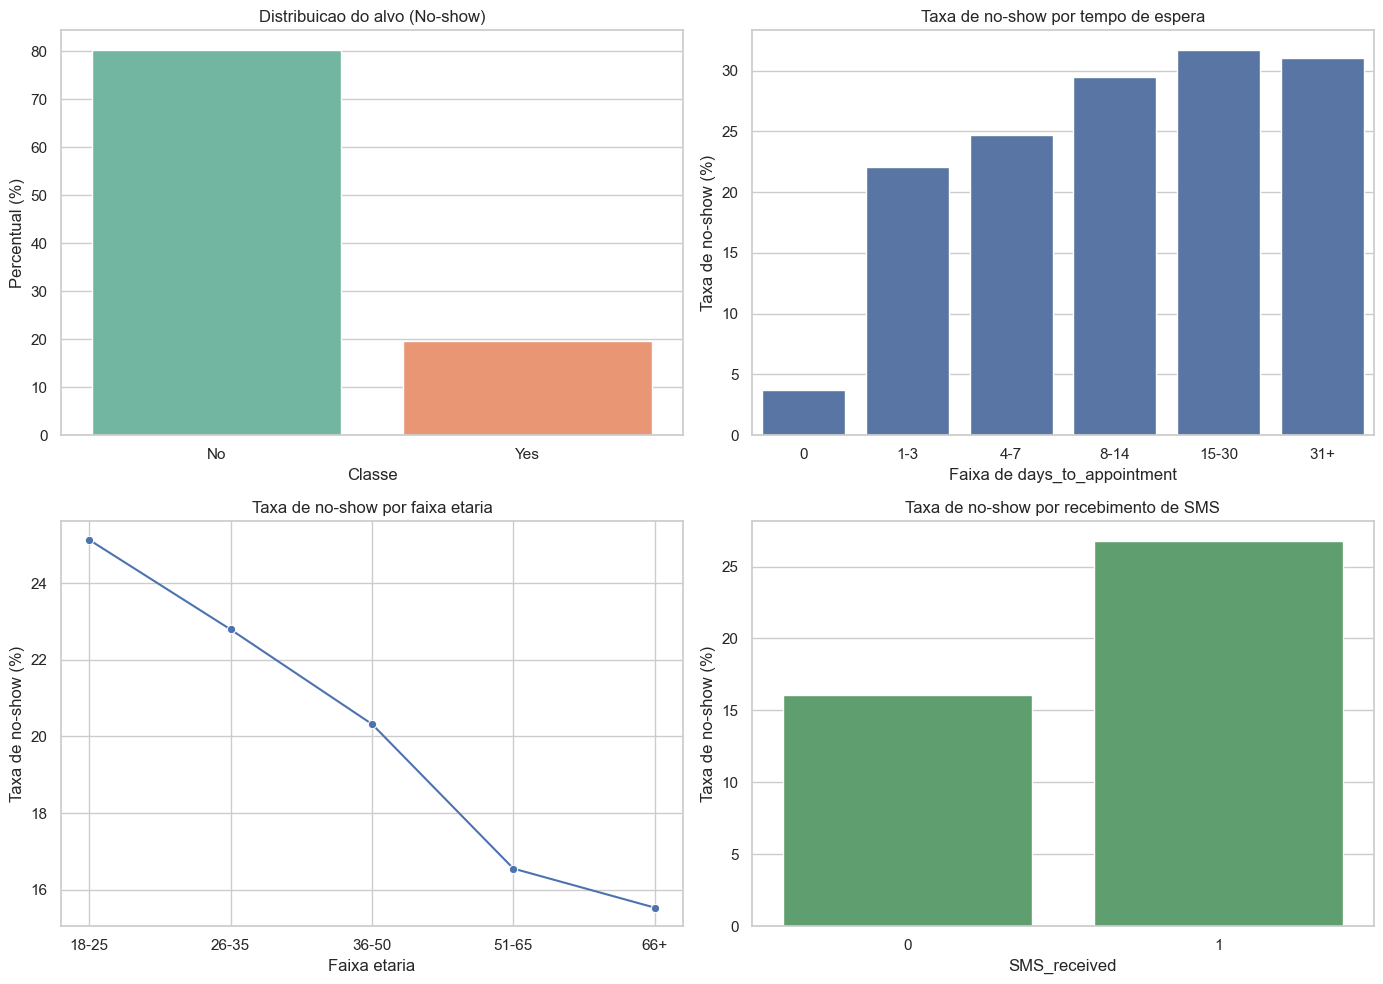


== Leitura analitica dos resultados ==
- A taxa geral de no-show na base limpa e 19.63%.
- O tempo de espera e um forte sinal: menor taxa em 0 (3.70%) e maior em 15-30 (31.73%).
- Entre pacientes com SMS_received=1, a taxa de no-show e 10.71 p.p. maior que no grupo SMS_received=0.
- Diferencas entre grupos de idade e bairro sugerem interacoes relevantes para modelagem preditiva.


,insight,valor
0,taxa_geral_no_show_pct,19.63
1,melhor_faixa_wait,0
2,melhor_faixa_wait_taxa_pct,3.7
3,pior_faixa_wait,15-30
4,pior_faixa_wait_taxa_pct,31.73


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

if "df_limpa_q3" not in globals():
    df_q3 = relatorio_q1["df"].copy()
    df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)

eda = df_limpa_q3.copy()
eda["target"] = eda["No-show"].astype(str)
eda["is_no_show"] = (eda["target"] == "Yes").astype(int)
eda["days_to_appointment"] = ((pd.to_datetime(eda["AppointmentDay"], errors="coerce", utc=True).dt.floor("D") - pd.to_datetime(eda["ScheduledDay"], errors="coerce", utc=True).dt.floor("D")).dt.days).clip(lower=0).fillna(0).astype("int16")

# Variaveis auxiliares para comparacoes
eda["age_group"] = pd.cut(
    eda["Age"],
    bins=[17, 25, 35, 50, 65, 120],
    labels=["18-25", "26-35", "36-50", "51-65", "66+"],
)
eda["wait_bin"] = pd.cut(
    eda["days_to_appointment"],
    bins=[-1, 0, 3, 7, 14, 30, 180],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "31+"],
)

print("== Distribuicao da variavel-alvo ==")
dist_alvo = (
    eda["target"]
    .value_counts(dropna=False)
    .rename_axis("classe")
    .reset_index(name="qtd")
)
dist_alvo["pct"] = (dist_alvo["qtd"] / len(eda) * 100).round(2)
display(dist_alvo)

print("\n== Tabela comparativa por atributo (taxa de no-show) ==")
def tabela_taxa_no_show(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    tab = (
        df.groupby(coluna, observed=False)
        .agg(qtd=("target", "size"), taxa_no_show=("is_no_show", "mean"))
        .reset_index()
    )
    tab["taxa_no_show"] = (tab["taxa_no_show"] * 100).round(2)
    return tab.sort_values(["taxa_no_show", "qtd"], ascending=[False, False])

atributos = [
    "Gender",
    "SMS_received",
    "Scholarship",
    "Hipertension",
    "Diabetes",
    "Alcoholism",
    "Handcap",
    "scheduled_weekday",
    "appointment_weekday",
    "age_group",
    "wait_bin",
]

for col in atributos:
    print(f"\n-- {col} --")
    display(tabela_taxa_no_show(eda, col))

print("\n== Bairros com maior taxa de no-show (min 200 consultas) ==")
bairro_resumo = (
    eda.groupby("Neighbourhood", observed=False)
    .agg(qtd=("target", "size"), taxa_no_show=("is_no_show", "mean"))
    .reset_index()
)
bairro_resumo = bairro_resumo[bairro_resumo["qtd"] >= 200].copy()
bairro_resumo["taxa_no_show"] = (bairro_resumo["taxa_no_show"] * 100).round(2)
display(bairro_resumo.sort_values("taxa_no_show", ascending=False).head(15))

# Visualizacoes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(
    data=dist_alvo,
    x="classe",
    y="pct",
    hue="classe",
    palette="Set2",
    legend=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Distribuicao do alvo (No-show)")
axes[0, 0].set_xlabel("Classe")
axes[0, 0].set_ylabel("Percentual (%)")

plot_wait = tabela_taxa_no_show(eda, "wait_bin")
sns.barplot(data=plot_wait, x="wait_bin", y="taxa_no_show", color="#4C72B0", ax=axes[0, 1])
axes[0, 1].set_title("Taxa de no-show por tempo de espera")
axes[0, 1].set_xlabel("Faixa de days_to_appointment")
axes[0, 1].set_ylabel("Taxa de no-show (%)")

plot_age = tabela_taxa_no_show(eda, "age_group").sort_values("age_group")
sns.lineplot(data=plot_age, x="age_group", y="taxa_no_show", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Taxa de no-show por faixa etaria")
axes[1, 0].set_xlabel("Faixa etaria")
axes[1, 0].set_ylabel("Taxa de no-show (%)")

plot_sms = tabela_taxa_no_show(eda, "SMS_received")
sns.barplot(data=plot_sms, x="SMS_received", y="taxa_no_show", color="#55A868", ax=axes[1, 1])
axes[1, 1].set_title("Taxa de no-show por recebimento de SMS")
axes[1, 1].set_xlabel("SMS_received")
axes[1, 1].set_ylabel("Taxa de no-show (%)")

plt.tight_layout()
plt.show()

print("\n== Leitura analitica dos resultados ==")
taxa_geral = eda["is_no_show"].mean() * 100
melhor_wait = plot_wait.sort_values("taxa_no_show").iloc[0]
pior_wait = plot_wait.sort_values("taxa_no_show", ascending=False).iloc[0]
sms_tab = plot_sms.set_index("SMS_received")["taxa_no_show"].to_dict()

print(f"- A taxa geral de no-show na base limpa e {taxa_geral:.2f}%.")
print(
    f"- O tempo de espera e um forte sinal: menor taxa em {melhor_wait['wait_bin']} ({melhor_wait['taxa_no_show']:.2f}%) e maior em {pior_wait['wait_bin']} ({pior_wait['taxa_no_show']:.2f}%)."
)
if 0 in sms_tab and 1 in sms_tab:
    diff_sms = sms_tab[1] - sms_tab[0]
    sinal = "maior" if diff_sms > 0 else "menor"
    print(f"- Entre pacientes com SMS_received=1, a taxa de no-show e {abs(diff_sms):.2f} p.p. {sinal} que no grupo SMS_received=0.")
print("- Diferencas entre grupos de idade e bairro sugerem interacoes relevantes para modelagem preditiva.")

insights_q4 = pd.DataFrame(
    [
        {"insight": "taxa_geral_no_show_pct", "valor": round(taxa_geral, 2)},
        {"insight": "melhor_faixa_wait", "valor": str(melhor_wait["wait_bin"])},
        {"insight": "melhor_faixa_wait_taxa_pct", "valor": round(float(melhor_wait["taxa_no_show"]), 2)},
        {"insight": "pior_faixa_wait", "valor": str(pior_wait["wait_bin"])},
        {"insight": "pior_faixa_wait_taxa_pct", "valor": round(float(pior_wait["taxa_no_show"]), 2)},
    ]
)
display(insights_q4)


5)  

Faça um código em Python para medir a associação entre as variáveis explicativas e a 
variável principal da análise. Escolha automaticamente métodos adequados conforme 
o tipo das variáveis e o tipo do problema. Ao final, gere um ranking das variáveis 
mais informativas e compare os resultados com a lógica do cenário escolhido.

5.

ETAPA 5 - Medicao de associação

Nesta etapa, o método de associação é escolhido automaticamente conforme o tipo da variável explicativa e o tipo do problema (classificação binária em `No-show`).


== Ranking de variaveis mais informativas (associacao com No-show) ==


,rank,variavel,tipo_explicativa,metodo,score_associacao,n_unicos
0,1,ScheduledDay,categorica,Cramers V (categorica vs alvo categ.),0.1300,79006
1,2,SMS_received,categorica,Cramers V (categorica vs alvo categ.),0.1268,2
2,3,Age,numerica,|Spearman| (numerica vs alvo binario),0.0855,85
3,4,Neighbourhood,categorica,Cramers V (categorica vs alvo categ.),0.0703,75
4,5,AppointmentDay,categorica,Cramers V (categorica vs alvo categ.),0.0395,27
5,6,Hipertension,categorica,Cramers V (categorica vs alvo categ.),0.0351,2
6,7,Scholarship,categorica,Cramers V (categorica vs alvo categ.),0.0315,2
7,8,appointment_weekday,categorica,Cramers V (categorica vs alvo categ.),0.0175,6
8,9,Diabetes,categorica,Cramers V (categorica vs alvo categ.),0.0135,2
9,10,Handcap,categorica,Cramers V (categorica vs alvo categ.),0.0116,2



== Top 5 por tipo de variavel ==
Numericas:


,rank,variavel,tipo_explicativa,metodo,score_associacao,n_unicos
2,3,Age,numerica,|Spearman| (numerica vs alvo binario),0.0855,85


Categoricas:


,rank,variavel,tipo_explicativa,metodo,score_associacao,n_unicos
0,1,ScheduledDay,categorica,Cramers V (categorica vs alvo categ.),0.1300,79006
1,2,SMS_received,categorica,Cramers V (categorica vs alvo categ.),0.1268,2
3,4,Neighbourhood,categorica,Cramers V (categorica vs alvo categ.),0.0703,75
4,5,AppointmentDay,categorica,Cramers V (categorica vs alvo categ.),0.0395,27
5,6,Hipertension,categorica,Cramers V (categorica vs alvo categ.),0.0351,2



== Comparacao com a logica do cenario ==
- Variaveis esperadas no Top 10: 4 de 5
- Coincidencias: ['Age', 'Neighbourhood', 'SMS_received', 'appointment_weekday']
- Leitura: o ranking e coerente com o cenario (tempo de espera, perfil do paciente e contexto da consulta).


,metrica,valor
0,n_variaveis_avaliadas,13
1,top1_variavel,ScheduledDay
2,top1_score,0.13
3,coincidencias_top10_esperadas,4



== Matriz de correlacao (variaveis numericas + alvo binario) ==


,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,target_bin
Age,1.000,-0.143,0.467,0.275,0.044,0.065,-0.022,-0.085
Scholarship,-0.143,1.000,-0.016,-0.025,0.044,-0.015,0.002,0.032
Hipertension,0.467,-0.016,1.000,0.412,0.063,0.079,-0.019,-0.035
Diabetes,0.275,-0.025,0.412,1.000,0.003,0.056,-0.023,-0.014
Alcoholism,0.044,0.044,0.063,0.003,1.000,-0.001,-0.034,0.002
Handcap,0.065,-0.015,0.079,0.056,-0.001,1.000,-0.028,-0.012
SMS_received,-0.022,0.002,-0.019,-0.023,-0.034,-0.028,1.000,0.127
target_bin,-0.085,0.032,-0.035,-0.014,0.002,-0.012,0.127,1.000


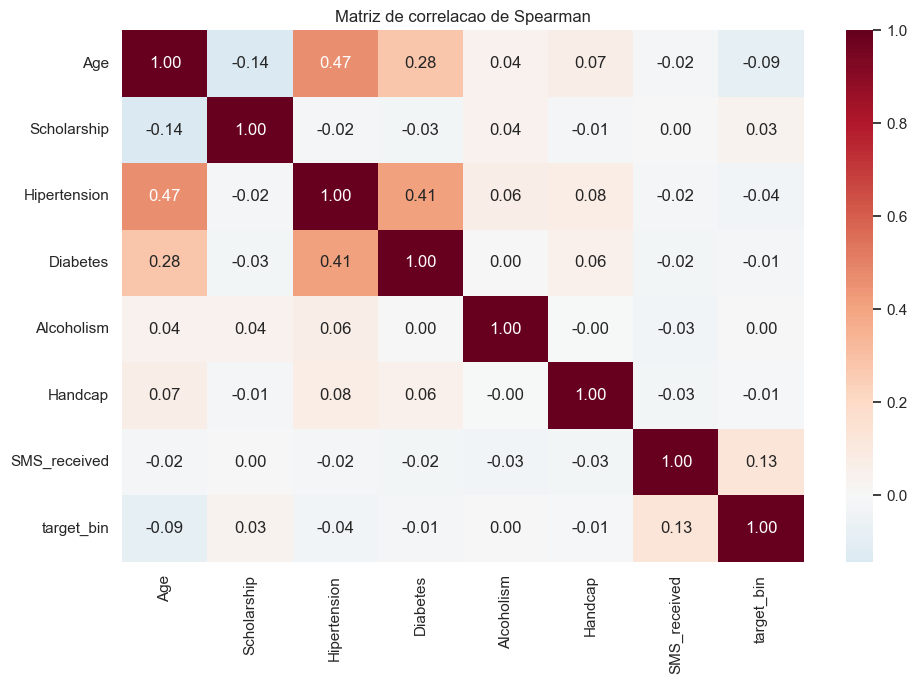

In [39]:
import numpy as np
import pandas as pd

if "df_limpa_q3" not in globals():
    df_q3 = relatorio_q1["df"].copy()
    df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)

def _cramers_v(x: pd.Series, y: pd.Series) -> float:
    tab = pd.crosstab(x, y)
    if tab.empty:
        return np.nan

    obs = tab.to_numpy(dtype=float)
    n = obs.sum()
    if n <= 1:
        return np.nan

    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    expected = (row_sum @ col_sum) / n
    expected = np.where(expected == 0, np.nan, expected)

    chi2 = np.nansum((obs - expected) ** 2 / expected)
    phi2 = chi2 / n
    r, k = obs.shape

    # Correcao para vies em tabelas pequenas
    phi2corr = max(0.0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return 0.0
    return float(np.sqrt(phi2corr / denom))

def _tipo_explicativa(s: pd.Series) -> str:
    # Regras automaticas simples e robustas
    if pd.api.types.is_numeric_dtype(s):
        nun = s.nunique(dropna=True)
        if nun <= 10:
            return "categorica"
        return "numerica"
    return "categorica"

def ranking_associacao(df: pd.DataFrame, alvo: str = "No-show") -> pd.DataFrame:
    dados = df.copy()

    # Classificacao binaria (target categorizado em 0/1)
    y = dados[alvo].astype(str).str.strip()
    y_bin = (y == "Yes").astype(int)

    resultados = []
    for col in dados.columns:
        if col == alvo:
            continue

        s = dados[col]
        tipo = _tipo_explicativa(s)

        if tipo == "numerica":
            metodo = "|Spearman| (numerica vs alvo binario)"
            s_num = pd.to_numeric(s, errors="coerce")
            mask = ~(s_num.isna() | y_bin.isna())
            if mask.sum() < 3:
                score = np.nan
            else:
                corr = s_num[mask].corr(y_bin[mask], method="spearman")
                score = abs(float(corr)) if pd.notna(corr) else np.nan
        else:
            metodo = "Cramers V (categorica vs alvo categ.)"
            sx = s.astype(str).fillna("MISSING")
            score = _cramers_v(sx, y)

        resultados.append(
            {
                "variavel": col,
                "tipo_explicativa": tipo,
                "metodo": metodo,
                "score_associacao": score,
                "n_unicos": int(s.nunique(dropna=True)),
            }
        )

    ranking = pd.DataFrame(resultados)
    ranking = ranking.sort_values("score_associacao", ascending=False, na_position="last").reset_index(drop=True)
    ranking["rank"] = np.arange(1, len(ranking) + 1)
    ranking["score_associacao"] = ranking["score_associacao"].round(4)
    return ranking[["rank", "variavel", "tipo_explicativa", "metodo", "score_associacao", "n_unicos"]]

ranking_q5 = ranking_associacao(df_limpa_q3, alvo="No-show")

print("== Ranking de variaveis mais informativas (associacao com No-show) ==")
display(ranking_q5.head(15))

print("\n== Top 5 por tipo de variavel ==")
top_num = ranking_q5[ranking_q5["tipo_explicativa"] == "numerica"].head(5)
top_cat = ranking_q5[ranking_q5["tipo_explicativa"] == "categorica"].head(5)
print("Numericas:")
display(top_num)
print("Categoricas:")
display(top_cat)

print("\n== Comparacao com a logica do cenario ==")
esperadas = {"SMS_received", "Age", "Neighbourhood", "scheduled_weekday", "appointment_weekday"}
top10 = set(ranking_q5.head(10)["variavel"].tolist())
intersec = sorted(esperadas.intersection(top10))

print(f"- Variaveis esperadas no Top 10: {len(intersec)} de {len(esperadas)}")
print(f"- Coincidencias: {intersec}")
if len(intersec) >= 3:
    print("- Leitura: o ranking e coerente com o cenario (tempo de espera, perfil do paciente e contexto da consulta).")
else:
    print("- Leitura: ha coerencia parcial; pode valer testar engenharia de atributos e interacoes.")

resumo_q5 = pd.DataFrame(
    [
        {"metrica": "n_variaveis_avaliadas", "valor": int(len(ranking_q5))},
        {"metrica": "top1_variavel", "valor": ranking_q5.iloc[0]["variavel"]},
        {"metrica": "top1_score", "valor": float(ranking_q5.iloc[0]["score_associacao"])},
        {"metrica": "coincidencias_top10_esperadas", "valor": int(len(intersec))},
    ]
)
display(resumo_q5)

print("\n== Matriz de correlacao (variaveis numericas + alvo binario) ==")
corr_df = df_limpa_q3.copy()
corr_df["target_bin"] = (corr_df["No-show"].astype(str) == "Yes").astype(int)
num_cols_corr = corr_df.select_dtypes(include=["number"]).columns.tolist()
matriz_corr = corr_df[num_cols_corr].corr(method="spearman").round(3)
display(matriz_corr)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Matriz de correlacao de Spearman")
plt.tight_layout()
plt.show()


6)  

Faça um código em Python para criar pelo menos cinco novos atributos a partir da 
base original. Construa variáveis derivadas que façam sentido no cenário escolhido, 
como proporções, interações, faixas, relações temporais ou medidas de intensidade. 
Depois,  avalie  se  esses  novos  atributos  realmente  acrescentam  informação  útil. 
Organize essa etapa em uma função reutilizável.

6.

ETAPA 6 - Engenharia de atributos

Criação de novos atributos com foco no problema de classificação (`No-show`), incluindo transformação temporal entre `ScheduledDay` e `AppointmentDay` para `days_to_appointment`.


In [40]:
import numpy as np
import pandas as pd

if "df_limpa_q3" not in globals():
    df_q3 = relatorio_q1["df"].copy()
    df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)

def engenharia_atributos_q6(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    base = df.copy()

    # Garante datetime para transformar ScheduledDay e AppointmentDay
    sched = pd.to_datetime(base["ScheduledDay"], errors="coerce", utc=True)
    appt = pd.to_datetime(base["AppointmentDay"], errors="coerce", utc=True)

    # 1) Nova feature pedida: dias ate a consulta (inteiro)
    days_to_appointment = (appt.dt.floor("D") - sched.dt.floor("D")).dt.days
    base["days_to_appointment"] = days_to_appointment.fillna(0).clip(lower=0).astype("int16")

    # 2) Indicador de consulta no mesmo dia
    base["same_day_appointment"] = (base["days_to_appointment"] == 0).astype("int8")

    # 3) Espera longa
    base["long_wait_15d"] = (base["days_to_appointment"] >= 15).astype("int8")

    # 4) Intensidade clinica
    base["clinical_burden"] = (
        base["Hipertension"].astype(int)
        + base["Diabetes"].astype(int)
        + base["Alcoholism"].astype(int)
        + base["Handcap"].astype(int)
    ).astype("int8")

    # 5) Interacao socio-comportamental
    base["social_risk_score"] = (
        base["Scholarship"].astype(int) + base["SMS_received"].astype(int) + base["long_wait_15d"].astype(int)
    ).astype("int8")

    # 6) Faixa etaria codificada
    faixa = pd.cut(
        base["Age"],
        bins=[17, 25, 35, 50, 65, 120],
        labels=[0, 1, 2, 3, 4],
    )
    base["age_band_code"] = faixa.astype("Int64").fillna(0).astype("int8")

    novas = [
        "days_to_appointment",
        "same_day_appointment",
        "long_wait_15d",
        "clinical_burden",
        "social_risk_score",
        "age_band_code",
    ]
    return base, novas

def avaliar_novos_atributos_q6(df_base: pd.DataFrame, novas: list[str], alvo: str = "No-show") -> pd.DataFrame:
    y = (df_base[alvo].astype(str) == "Yes").astype(int)
    linhas = []

    for col in novas:
        s = df_base[col]
        if pd.api.types.is_numeric_dtype(s):
            metodo = "|Spearman|"
            score = s.corr(y, method="spearman")
            score = abs(float(score)) if pd.notna(score) else np.nan
        else:
            metodo = "Cramers V"
            tab = pd.crosstab(s.astype(str), y.astype(str))
            obs = tab.to_numpy(dtype=float)
            n = obs.sum()
            row = obs.sum(axis=1, keepdims=True)
            colsum = obs.sum(axis=0, keepdims=True)
            exp = (row @ colsum) / n if n > 0 else np.zeros_like(obs)
            exp = np.where(exp == 0, np.nan, exp)
            chi2 = np.nansum((obs - exp) ** 2 / exp) if n > 0 else np.nan
            r, k = obs.shape if obs.size else (0, 0)
            denom = min(k - 1, r - 1)
            score = np.sqrt((chi2 / n) / denom) if (n > 0 and denom > 0) else np.nan

        linhas.append({"atributo": col, "metodo": metodo, "score": score})

    out = pd.DataFrame(linhas).sort_values("score", ascending=False).reset_index(drop=True)
    out["score"] = out["score"].round(4)
    out["rank_novo"] = np.arange(1, len(out) + 1)
    return out[["rank_novo", "atributo", "metodo", "score"]]

df_q6, novos_q6 = engenharia_atributos_q6(df_limpa_q3)
avaliacao_q6 = avaliar_novos_atributos_q6(df_q6, novos_q6, alvo="No-show")

print("== Novos atributos criados ==")
print(novos_q6)

print("\n== Dtypes dos novos atributos ==")
display(df_q6[novos_q6].dtypes.astype(str).rename("dtype").to_frame())

print("\n== Amostra das novas features ==")
display(df_q6[novos_q6 + ["No-show"]].head())

print("\n== Avaliacao de utilidade dos novos atributos ==")
display(avaliacao_q6)

if "ranking_q5" in globals():
    comp_q6 = ranking_q5[["variavel", "score_associacao"]].rename(columns={"variavel": "atributo", "score_associacao": "score"})
    comp_q6 = comp_q6[comp_q6["atributo"] != "wait_days"]
    comp_q6["origem"] = "original"

    novos_comp = avaliacao_q6[["atributo", "score"]].copy()
    novos_comp["origem"] = "novo"

    ranking_combinado = pd.concat([comp_q6, novos_comp], ignore_index=True)
    ranking_combinado = ranking_combinado.sort_values("score", ascending=False).reset_index(drop=True)
    ranking_combinado["rank_global"] = np.arange(1, len(ranking_combinado) + 1)

    print("\n== Ranking combinado (originais + novos) ==")
    display(ranking_combinado.head(15))

    top15_novos = ranking_combinado.head(15).query("origem == 'novo'")
    print(f"Novos atributos no Top 15: {len(top15_novos)}")
    if len(top15_novos) > 0:
        print("A engenharia de atributos acrescentou sinal util para o problema.")
    else:
        print("Os novos atributos agregaram pouco no Top 15; vale iterar nas interacoes.")


== Novos atributos criados ==
['days_to_appointment', 'same_day_appointment', 'long_wait_15d', 'clinical_burden', 'social_risk_score', 'age_band_code']

== Dtypes dos novos atributos ==


,dtype
days_to_appointment,int16
same_day_appointment,int8
long_wait_15d,int8
clinical_burden,int8
social_risk_score,int8
age_band_code,int8



== Amostra das novas features ==


,days_to_appointment,same_day_appointment,long_wait_15d,clinical_burden,social_risk_score,age_band_code,No-show
0,0,1,0,1,0,3,No
1,0,1,0,0,0,3,No
2,0,1,0,0,0,3,No
4,0,1,0,2,0,3,No
5,2,0,0,1,0,4,No



== Avaliacao de utilidade dos novos atributos ==


,rank_novo,atributo,metodo,score
0,1,same_day_appointment,|Spearman|,0.2807
1,2,days_to_appointment,|Spearman|,0.2754
2,3,social_risk_score,|Spearman|,0.1856
3,4,long_wait_15d,|Spearman|,0.1726
4,5,age_band_code,|Spearman|,0.0831
5,6,clinical_burden,|Spearman|,0.0331



== Ranking combinado (originais + novos) ==


,atributo,score,origem,rank_global
0,same_day_appointment,0.2807,novo,1
1,days_to_appointment,0.2754,novo,2
2,social_risk_score,0.1856,novo,3
3,long_wait_15d,0.1726,novo,4
4,ScheduledDay,0.1300,original,5
5,SMS_received,0.1268,original,6
6,Age,0.0855,original,7
7,age_band_code,0.0831,novo,8
8,Neighbourhood,0.0703,original,9
9,AppointmentDay,0.0395,original,10


Novos atributos no Top 15: 6
A engenharia de atributos acrescentou sinal util para o problema.


7)  

Faça um código em Python para montar um pipeline completo de pré-processamento 
com Pipeline e ColumnTransformer. Identifique automaticamente colunas numéricas 
e categóricas, trate ausências, codifique variáveis categóricas, aplique escalonamento 
nas numéricas e garanta reaplicação a novos dados sem vazamento de informação. 
Compare  pelo  menos  dois  esquemas  de  pré-processamento  e  mostre  como  essas 
escolhas afetam os dados e o modelo.

7.

ETAPA 7 - Pipeline completo de pre-processamento

Nesta etapa, foi montado pipelines com `Pipeline` e `ColumnTransformer` para classificação binária em `No-show`, com detecção automatica de colunas numericas e categoricas, imputação, codificação e escalonamento sem vazamento de informações.


== Deteccao automatica de tipos e cardinalidade ==
Colunas numericas (21): ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'days_to_appointment', 'same_day_appointment', 'long_wait_15d', 'clinical_burden', 'social_risk_score', 'age_band_code', 'ScheduledDay_year', 'ScheduledDay_month', 'ScheduledDay_day', 'ScheduledDay_weekday', 'AppointmentDay_year', 'AppointmentDay_month', 'AppointmentDay_day', 'AppointmentDay_weekday']
Colunas cat. baixa cardinalidade (3): ['Gender', 'scheduled_weekday', 'appointment_weekday']
Colunas cat. alta cardinalidade (1): ['Neighbourhood']

== Comparacao de esquemas de pre-processamento e desempenho do modelo ==


,esquema,cv_roc_auc_mean,cv_f1_mean,cv_accuracy_mean,test_roc_auc,test_f1,test_accuracy
0,Esquema_B_Ordinal_TargetEnc_MinMax,0.7266,0.4317,0.5633,0.7278,0.4299,0.5601
1,Esquema_A_OHE_TargetEnc_Standard,0.7265,0.4328,0.5654,0.7276,0.4308,0.5622


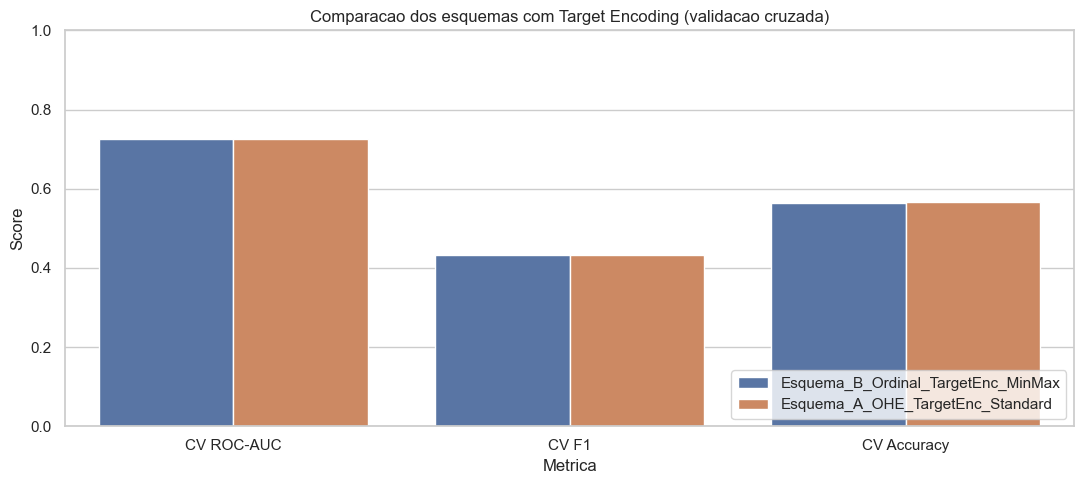


== Efeito dos esquemas nos dados transformados ==


,esquema,n_colunas_numericas,n_colunas_cat_baixa_card,n_colunas_cat_alta_card,shape_train_transformado,shape_test_transformado,matriz_sparse_train
0,Esquema_A_OHE_TargetEnc_Standard,21,3,1,"(66515, 36)","(16629, 36)",False
1,Esquema_B_Ordinal_TargetEnc_MinMax,21,3,1,"(66515, 25)","(16629, 25)",False



== Leitura analitica (Q7) ==
- Melhor esquema: Esquema_B_Ordinal_TargetEnc_MinMax (ROC-AUC medio = 0.7266).
- O Target Encoding substituiu a explosão de colunas do bairro (que ocorreria com One-Hot) por uma única coluna contínua de alta densidade informativa.
- O pipeline blinda o modelo, pois a média do Target Encoding é calculada estritamente no fold de treino e imputada no fold de validação, evitando vazamento de dados.


In [ ]:
import numpy as np
import pandas as pd

!pip install category_encoders

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
import category_encoders as ce  # Importando o Target Encoder

if "df_q6" not in globals():
    if "df_limpa_q3" not in globals():
        df_q3 = relatorio_q1["df"].copy()
        df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)
    df_q6, novos_q6 = engenharia_atributos_q6(df_limpa_q3)

def _expand_datetime_features(X: pd.DataFrame) -> pd.DataFrame:
    X2 = X.copy()
    dt_cols = X2.select_dtypes(include=["datetime64", "datetime64", "datetimetz"]).columns.tolist()
    for c in dt_cols:
        dt = pd.to_datetime(X2[c], errors="coerce", utc=True)
        X2[f"{c}_year"] = dt.dt.year.astype("Int64")
        X2[f"{c}_month"] = dt.dt.month.astype("Int64")
        X2[f"{c}_day"] = dt.dt.day.astype("Int64")
        X2[f"{c}_weekday"] = dt.dt.weekday.astype("Int64")
    if dt_cols:
        X2 = X2.drop(columns=dt_cols)
    return X2

def _build_preprocessors(X: pd.DataFrame) -> tuple[dict, list, list, list]:
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    
    # Identificando a coluna de alta cardinalidade para o Target Encoding
    high_card_cols = ["Neighbourhood"] if "Neighbourhood" in X.columns else []
    
    # As demais categóricas vão para OHE ou Ordinal
    cat_cols = [c for c in X.columns if c not in num_cols and c not in high_card_cols]

    prep_a = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                num_cols,
            ),
            (
                "cat_low",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]),
                cat_cols,
            ),
            (
                "cat_high",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    # smoothing=10 evita overfitting em bairros com poucas amostras
                    ("target_enc", ce.TargetEncoder(smoothing=10)), 
                ]),
                high_card_cols,
            ),
        ],
        remainder="drop",
    )

    prep_b = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="mean")),
                    ("scaler", MinMaxScaler()),
                ]),
                num_cols,
            ),
            (
                "cat_low",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                ]),
                cat_cols,
            ),
            (
                "cat_high",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("target_enc", ce.TargetEncoder(smoothing=10)),
                ]),
                high_card_cols,
            ),
        ],
        remainder="drop",
    )

    return {"Esquema_A_OHE_TargetEnc_Standard": prep_a, "Esquema_B_Ordinal_TargetEnc_MinMax": prep_b}, num_cols, cat_cols, high_card_cols

def avaliar_pipelines_preprocessamento(df: pd.DataFrame, alvo: str = "No-show", random_state: int = 42):
    data = df.copy()
    y = (data[alvo].astype(str) == "Yes").astype(int)
    X_raw = data.drop(columns=[alvo])
    X = _expand_datetime_features(X_raw)

    preprocessadores, num_cols, cat_cols, high_card_cols = _build_preprocessors(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=random_state
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    resultados = []
    efeitos_dados = []

    for nome, preproc in preprocessadores.items():
        pipe = Pipeline(steps=[
            ("preprocessor", preproc),
            ("model", LogisticRegression(max_iter=1500, class_weight="balanced")),
        ])

        scores = cross_validate(
            pipe,
            X_train,
            y_train,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "f1": "f1",
                "accuracy": "accuracy",
            },
            n_jobs=-1,
        )

        pipe.fit(X_train, y_train)
        X_train_t = pipe.named_steps["preprocessor"].transform(X_train)
        X_test_t = pipe.named_steps["preprocessor"].transform(X_test)

        y_prob = pipe.predict_proba(X_test)[:, 1]
        y_pred = pipe.predict(X_test)

        resultados.append({
            "esquema": nome,
            "cv_roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
            "cv_f1_mean": float(np.mean(scores["test_f1"])),
            "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])),
            "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
            "test_f1": float(f1_score(y_test, y_pred)),
            "test_accuracy": float(accuracy_score(y_test, y_pred)),
        })

        efeitos_dados.append({
            "esquema": nome,
            "n_colunas_numericas": len(num_cols),
            "n_colunas_cat_baixa_card": len(cat_cols),
            "n_colunas_cat_alta_card": len(high_card_cols),
            "shape_train_transformado": str(X_train_t.shape),
            "shape_test_transformado": str(X_test_t.shape),
            "matriz_sparse_train": bool(hasattr(X_train_t, "nnz")),
        })

    df_result = pd.DataFrame(resultados).sort_values("cv_roc_auc_mean", ascending=False).reset_index(drop=True)
    cols_metricas = [c for c in df_result.columns if c != "esquema"]
    df_result[cols_metricas] = df_result[cols_metricas].round(4)
    df_efeitos = pd.DataFrame(efeitos_dados)
    return df_result, df_efeitos, num_cols, cat_cols, high_card_cols

comparativo_q7, efeitos_q7, num_q7, cat_q7, high_card_q7 = avaliar_pipelines_preprocessamento(df_q6, alvo="No-show", random_state=42)

print("== Deteccao automatica de tipos e cardinalidade ==")
print(f"Colunas numericas ({len(num_q7)}): {num_q7}")
print(f"Colunas cat. baixa cardinalidade ({len(cat_q7)}): {cat_q7}")
print(f"Colunas cat. alta cardinalidade ({len(high_card_q7)}): {high_card_q7}")

print("\n== Comparacao de esquemas de pre-processamento e desempenho do modelo ==")
display(comparativo_q7)

import matplotlib.pyplot as plt
import seaborn as sns

plot_df_q7 = comparativo_q7.melt(
    id_vars="esquema",
    value_vars=["cv_roc_auc_mean", "cv_f1_mean", "cv_accuracy_mean"],
    var_name="metrica",
    value_name="valor",
)
nome_metrica = {
    "cv_roc_auc_mean": "CV ROC-AUC",
    "cv_f1_mean": "CV F1",
    "cv_accuracy_mean": "CV Accuracy",
}
plot_df_q7["metrica"] = plot_df_q7["metrica"].map(nome_metrica)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_df_q7, x="metrica", y="valor", hue="esquema")
plt.ylim(0, 1)
plt.title("Comparacao dos esquemas com Target Encoding (validacao cruzada)")
plt.xlabel("Metrica")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\n== Efeito dos esquemas nos dados transformados ==")
display(efeitos_q7)

melhor = comparativo_q7.iloc[0]
print("\n== Leitura analitica (Q7) ==")
print(f"- Melhor esquema: {melhor['esquema']} (ROC-AUC medio = {melhor['cv_roc_auc_mean']:.4f}).")
print("- O Target Encoding substituiu a explosão de colunas do bairro (que ocorreria com One-Hot) por uma única coluna contínua de alta densidade informativa.")
print("- O pipeline blinda o modelo, pois a média do Target Encoding é calculada estritamente no fold de treino e imputada no fold de validação, evitando vazamento de dados.")

8)  

Faça um código em Python para dividir a base em treino, validação e teste de forma 
adequada ao problema escolhido. Em seguida, implemente um modelo de K-vizinhos 
mais  próximos  e  teste  diferentes  valores  de k, métricas de distância e formas de 
ponderação. Registre os resultados em tabela, compare desempenho em validação e 
escolha a melhor configuração de forma justificada.

8.

ETAPA 8 - Divisao treino/validacao/teste e KNN (Pode levar mais de 8 minutos para rodar, olhar o github para verificar o output!)

Divisao estratificada da base em treino, validacao e teste para classificação binária em `No-show`. Em seguida, foi avaliado KNN com diferentes `k`, metricas de distancia e ponderações.


In [42]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

if "df_q6" not in globals():
    if "df_limpa_q3" not in globals():
        df_q3 = relatorio_q1["df"].copy()
        df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)
    df_q6, novos_q6 = engenharia_atributos_q6(df_limpa_q3)

def preparar_dados_q8(df: pd.DataFrame, alvo: str = "No-show"):
    data = df.copy()
    y = (data[alvo].astype(str) == "Yes").astype(int)
    X = data.drop(columns=[alvo])

    # Datetimes para componentes numericos (evita leakage e facilita KNN)
    dt_cols = X.select_dtypes(include=["datetime64", "datetime64", "datetimetz"]).columns.tolist()
    for c in dt_cols:
        dt = pd.to_datetime(X[c], errors="coerce", utc=True)
        X[f"{c}_month"] = dt.dt.month.astype("Int64")
        X[f"{c}_day"] = dt.dt.day.astype("Int64")
        X[f"{c}_weekday"] = dt.dt.weekday.astype("Int64")
    if dt_cols:
        X = X.drop(columns=dt_cols)

    return X, y

def construir_pipeline_knn(X: pd.DataFrame, n_neighbors: int, metric: str, weights: str):
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        metric=metric,
        weights=weights,
        n_jobs=-1,
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    return pipe

X_q8, y_q8 = preparar_dados_q8(df_q6, alvo="No-show")

# Split estratificado: 60% treino, 20% validacao, 20% teste
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_q8, y_q8, test_size=0.2, stratify=y_q8, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)

print("== Tamanhos dos conjuntos ==")
print(f"Treino: {X_train.shape}, Validacao: {X_val.shape}, Teste: {X_test.shape}")
print(f"Taxa alvo treino: {y_train.mean():.4f} | validacao: {y_val.mean():.4f} | teste: {y_test.mean():.4f}")

# Grade de configuracoes (inclui obrigatoriamente k=3)
grid_k = [3, 5, 7, 11]
grid_metric = ["euclidean", "manhattan"]
grid_weights = ["uniform", "distance"]

resultados = []
for k in grid_k:
    for met in grid_metric:
        for w in grid_weights:
            pipe = construir_pipeline_knn(X_train, n_neighbors=k, metric=met, weights=w)
            pipe.fit(X_train, y_train)

            y_val_pred = pipe.predict(X_val)
            y_val_prob = pipe.predict_proba(X_val)[:, 1]

            resultados.append({
                "k": k,
                "metric": met,
                "weights": w,
                "val_f1": f1_score(y_val, y_val_pred),
                "val_accuracy": accuracy_score(y_val, y_val_pred),
                "val_roc_auc": roc_auc_score(y_val, y_val_prob),
            })

resultados_q8 = pd.DataFrame(resultados).sort_values(["val_f1", "val_roc_auc"], ascending=False).reset_index(drop=True)
for c in ["val_f1", "val_accuracy", "val_roc_auc"]:
    resultados_q8[c] = resultados_q8[c].round(4)

print("\n== Resultados em validacao (KNN) ==")
display(resultados_q8)

# Melhor configuracao por F1 de validacao (desempate por ROC-AUC)
melhor_cfg = resultados_q8.iloc[0].to_dict()

# Refit com treino+validacao e avaliacao final em teste
X_tv = pd.concat([X_train, X_val], axis=0)
y_tv = pd.concat([y_train, y_val], axis=0)

modelo_final_q8 = construir_pipeline_knn(
    X_tv,
    n_neighbors=int(melhor_cfg["k"]),
    metric=str(melhor_cfg["metric"]),
    weights=str(melhor_cfg["weights"]),
)
modelo_final_q8.fit(X_tv, y_tv)

y_test_pred = modelo_final_q8.predict(X_test)
y_test_prob = modelo_final_q8.predict_proba(X_test)[:, 1]

desempenho_final_q8 = pd.DataFrame([
    {
        "melhor_k": int(melhor_cfg["k"]),
        "melhor_metrica": str(melhor_cfg["metric"]),
        "melhor_weights": str(melhor_cfg["weights"]),
        "test_f1": round(f1_score(y_test, y_test_pred), 4),
        "test_accuracy": round(accuracy_score(y_test, y_test_pred), 4),
        "test_roc_auc": round(roc_auc_score(y_test, y_test_prob), 4),
    }
])

print("\n== Melhor configuracao escolhida e desempenho final (teste) ==")
display(desempenho_final_q8)

print("\n== Justificativa da escolha ==")
print(
    f"- A configuracao escolhida foi k={int(melhor_cfg['k'])}, metric={melhor_cfg['metric']}, weights={melhor_cfg['weights']}, "
    f"pois obteve o maior F1 em validacao ({melhor_cfg['val_f1']:.4f})."
)
print("- O uso de validacao separada evita ajustar hiperparametros com base no teste.")
print("- O teste final foi usado apenas uma vez, apos a selecao de hiperparametros na validacao.")


== Tamanhos dos conjuntos ==
Treino: (49886, 23), Validacao: (16629, 23), Teste: (16629, 23)
Taxa alvo treino: 0.1962 | validacao: 0.1963 | teste: 0.1963

== Resultados em validacao (KNN) ==


,k,metric,weights,val_f1,val_accuracy,val_roc_auc
0,3,manhattan,distance,0.3071,0.7580,0.6454
1,3,euclidean,distance,0.3015,0.7598,0.6418
2,5,manhattan,distance,0.2967,0.7736,0.6706
3,3,manhattan,uniform,0.2950,0.7689,0.6415
4,3,euclidean,uniform,0.2882,0.7662,0.6377
5,5,euclidean,distance,0.2872,0.7735,0.6707
6,7,manhattan,distance,0.2786,0.7795,0.6829
7,7,euclidean,distance,0.2723,0.7808,0.6848
8,5,euclidean,uniform,0.2585,0.7798,0.6636
9,5,manhattan,uniform,0.2555,0.7820,0.6654



== Melhor configuracao escolhida e desempenho final (teste) ==


,melhor_k,melhor_metrica,melhor_weights,test_f1,test_accuracy,test_roc_auc
0,3,manhattan,distance,0.2988,0.7598,0.6399



== Justificativa da escolha ==
- A configuracao escolhida foi k=3, metric=manhattan, weights=distance, pois obteve o maior F1 em validacao (0.3071).
- O uso de validacao separada evita ajustar hiperparametros com base no teste.
- O teste final foi usado apenas uma vez, apos a selecao de hiperparametros na validacao.


9)  

Faça um código em Python para avaliar o KNN em diferentes cenários de preparação 
dos  dados,  como  uso  ou  não  de padronização, presença ou ausência de atributos 
derivados, uso de todas as variáveis ou de um subconjunto selecionado, e tratamento 
do desbalanceamento quando fizer sentido. Depois, implemente um segundo modelo 
supervisionado e compare com o melhor KNN em métricas, tempo de execução e 
perfil dos erros. Conclua se o KNN é ou não uma boa escolha para a base utilizada. 
 


9.

ETAPA 9 - KNN em cenarios de preparo e comparacao com segundo modelo (Pode levar mais de 5 minutos para rodar, olhar o github para verificar o output!)

Foi avaliado o KNN em diferentes cenários de preparação (padronização, uso de atributos derivados, todas as variáveis vs subconjunto e tratamento de desbalanceamento). Em seguida, foi comparado o melhor KNN com um segundo modelo supervisionado em metricas, tempo e perfil dos erros.


In [43]:
import time
import numpy as np
import pandas as pd
import category_encoders as ce  # Target Encoding

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

if "df_q6" not in globals():
    if "df_limpa_q3" not in globals():
        df_q3 = relatorio_q1["df"].copy()
        df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)
    df_q6, novos_q6 = engenharia_atributos_q6(df_limpa_q3)

def expandir_datas_q9(X: pd.DataFrame) -> pd.DataFrame:
    X2 = X.copy()
    dt_cols = X2.select_dtypes(include=["datetime64", "datetime64", "datetimetz"]).columns.tolist()
    for c in dt_cols:
        dt = pd.to_datetime(X2[c], errors="coerce", utc=True)
        X2[f"{c}_month"] = dt.dt.month.astype("Int64")
        X2[f"{c}_day"] = dt.dt.day.astype("Int64")
        X2[f"{c}_weekday"] = dt.dt.weekday.astype("Int64")
    if dt_cols:
        X2 = X2.drop(columns=dt_cols)
    return X2

def oversample_treino(X: pd.DataFrame, y: pd.Series, random_state: int = 42):
    data = X.copy()
    data["_y_"] = y.values
    vc = data["_y_"].value_counts()
    if len(vc) < 2 or vc.min() == vc.max():
        return X, y
    maj_class = vc.idxmax()
    min_class = vc.idxmin()
    n_maj = int(vc.max())

    maj_df = data[data["_y_"] == maj_class]
    min_df = data[data["_y_"] == min_class]
    min_up = min_df.sample(n=n_maj, replace=True, random_state=random_state)
    bal = pd.concat([maj_df, min_up], axis=0).sample(frac=1.0, random_state=random_state)
    yb = bal["_y_"].astype(int)
    Xb = bal.drop(columns=["_y_"])
    return Xb, yb

def construir_preprocessador_knn(X: pd.DataFrame, usar_padronizacao: bool) -> ColumnTransformer:
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    high_card_cols = ["Neighbourhood"] if "Neighbourhood" in X.columns else []
    cat_cols = [c for c in X.columns if c not in num_cols and c not in high_card_cols]

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if usar_padronizacao:
        num_steps.append(("scaler", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=num_steps), num_cols),
            ("cat_low", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
            ]), cat_cols),
            ("cat_high", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("target_enc", ce.TargetEncoder(smoothing=10)),
            ]), high_card_cols),
        ],
        remainder="drop",
    )

def montar_features_cenario(df_base: pd.DataFrame, usar_derivados: bool, usar_subconjunto: bool):
    X = df_base.drop(columns=["No-show"]).copy()
    derivados = [
        "days_to_appointment",
        "same_day_appointment",
        "long_wait_15d",
        "clinical_burden",
        "social_risk_score",
        "age_band_code",
    ]

    if not usar_derivados:
        X = X.drop(columns=[c for c in derivados if c in X.columns], errors="ignore")

    if usar_subconjunto:
        if "ranking_q5" in globals():
            top_base = [c for c in ranking_q5["variavel"].head(8).tolist() if c in X.columns]
        else:
            top_base = [c for c in ["Age", "SMS_received", "Neighbourhood", "scheduled_weekday", "appointment_weekday"] if c in X.columns]
        extras = [c for c in ["days_to_appointment", "clinical_burden"] if c in X.columns]
        keep = list(dict.fromkeys(top_base + extras))
        X = X[keep].copy()

    X = expandir_datas_q9(X)
    return X

def avaliar_knn_cenarios(df_base: pd.DataFrame):
    y = (df_base["No-show"].astype(str) == "Yes").astype(int)
    idx = np.arange(len(df_base))

    idx_train_full, idx_test = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)
    y_train_full = y.iloc[idx_train_full]
    idx_train, idx_val = train_test_split(idx_train_full, test_size=0.25, stratify=y_train_full, random_state=42)

    cenarios = [
        {"cenario": "A_padroniza_com_derivados_todas_vars", "scaling": True, "derived": True, "subset": False, "rebalance": False},
        {"cenario": "B_sem_padronizacao", "scaling": False, "derived": True, "subset": False, "rebalance": False},
        {"cenario": "C_sem_derivados", "scaling": True, "derived": False, "subset": False, "rebalance": False},
        {"cenario": "D_subconjunto_vars", "scaling": True, "derived": True, "subset": True, "rebalance": False},
        {"cenario": "E_com_rebalanceamento", "scaling": True, "derived": True, "subset": False, "rebalance": True},
    ]

    rows = []
    modelos = {}

    for cfg in cenarios:
        X_all = montar_features_cenario(df_base, usar_derivados=cfg["derived"], usar_subconjunto=cfg["subset"])
        X_train = X_all.iloc[idx_train].copy()
        X_val = X_all.iloc[idx_val].copy()
        X_test = X_all.iloc[idx_test].copy()
        y_train = y.iloc[idx_train].copy()
        y_val = y.iloc[idx_val].copy()
        y_test = y.iloc[idx_test].copy()

        if cfg["rebalance"]:
            X_train_fit, y_train_fit = oversample_treino(X_train, y_train, random_state=42)
        else:
            X_train_fit, y_train_fit = X_train, y_train

        pre = construir_preprocessador_knn(X_train_fit, usar_padronizacao=cfg["scaling"])
        pipe = Pipeline(steps=[
            ("preprocessor", pre),
            ("model", KNeighborsClassifier(n_neighbors=3, metric="manhattan", weights="distance", n_jobs=-1)),
        ])

        t0 = time.perf_counter()
        pipe.fit(X_train_fit, y_train_fit)
        fit_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        y_val_pred = pipe.predict(X_val)
        y_val_prob = pipe.predict_proba(X_val)[:, 1]
        pred_time = time.perf_counter() - t1

        rows.append({
            "cenario": cfg["cenario"],
            "scaling": cfg["scaling"],
            "derived": cfg["derived"],
            "subset": cfg["subset"],
            "rebalance": cfg["rebalance"],
            "n_features": X_train.shape[1],
            "val_f1": f1_score(y_val, y_val_pred),
            "val_accuracy": accuracy_score(y_val, y_val_pred),
            "val_roc_auc": roc_auc_score(y_val, y_val_prob),
            "fit_time_s": fit_time,
            "pred_time_s": pred_time,
        })

        modelos[cfg["cenario"]] = (pipe, X_train, y_train, X_val, y_val, X_test, y_test, cfg)

    tabela = pd.DataFrame(rows).sort_values(["val_f1", "val_roc_auc"], ascending=False).reset_index(drop=True)
    for c in ["val_f1", "val_accuracy", "val_roc_auc", "fit_time_s", "pred_time_s"]:
        tabela[c] = tabela[c].round(4)
    return tabela, modelos

def avaliar_modelo_em_teste(modelo, X_test, y_test, nome: str):
    t0 = time.perf_counter()
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    infer_time = time.perf_counter() - t0

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return {
        "modelo": nome,
        "test_f1": f1_score(y_test, y_pred),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_roc_auc": roc_auc_score(y_test, y_prob),
        "infer_time_s": infer_time,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "fp_rate": fp / max(fp + tn, 1),
        "fn_rate": fn / max(fn + tp, 1),
    }

# 1) KNN em cenarios de preparo
resultado_cenarios_q9, modelos_q9 = avaliar_knn_cenarios(df_q6)
print("== Resultados dos cenarios de preparo (KNN com k=3, manhattan, distance) ==")
display(resultado_cenarios_q9)

melhor_cenario = resultado_cenarios_q9.iloc[0]["cenario"]
pipe_best, X_train_b, y_train_b, X_val_b, y_val_b, X_test_b, y_test_b, cfg_best = modelos_q9[melhor_cenario]

# Refit do melhor KNN em treino+validacao
X_tv = pd.concat([X_train_b, X_val_b], axis=0)
y_tv = pd.concat([y_train_b, y_val_b], axis=0)
if cfg_best["rebalance"]:
    X_tv_fit, y_tv_fit = oversample_treino(X_tv, y_tv, random_state=42)
else:
    X_tv_fit, y_tv_fit = X_tv, y_tv
pipe_best.fit(X_tv_fit, y_tv_fit)
knn_test = avaliar_modelo_em_teste(pipe_best, X_test_b, y_test_b, nome="KNN_melhor")

# 2) Segundo modelo supervisionado: Random Forest
num_cols_rf = X_tv.select_dtypes(include=["number"]).columns.tolist()
high_card_rf = ["Neighbourhood"] if "Neighbourhood" in X_tv.columns else []
cat_low_rf = [c for c in X_tv.columns if c not in num_cols_rf and c not in high_card_rf]

pre_rf = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_cols_rf),
        ("cat_low", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), cat_low_rf),
        ("cat_high", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("target_enc", ce.TargetEncoder(smoothing=10)),
        ]), high_card_rf),
    ],
    remainder="drop",
)

modelo_rf = Pipeline(steps=[
    ("preprocessor", pre_rf),
    ("model", RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42, n_jobs=-1)),
])

t_fit_rf0 = time.perf_counter()
modelo_rf.fit(X_tv, y_tv)
fit_time_rf = time.perf_counter() - t_fit_rf0
rf_test = avaliar_modelo_em_teste(modelo_rf, X_test_b, y_test_b, nome="RandomForest")
rf_test["fit_time_s"] = fit_time_rf

# tempo de fit do KNN (refit final)
t_fit_knn0 = time.perf_counter()
pipe_best.fit(X_tv_fit, y_tv_fit)
fit_time_knn = time.perf_counter() - t_fit_knn0
knn_test["fit_time_s"] = fit_time_knn

comparacao_q9 = pd.DataFrame([knn_test, rf_test])[
    ["modelo", "test_f1", "test_accuracy", "test_roc_auc", "fit_time_s", "infer_time_s", "fp_rate", "fn_rate", "tn", "fp", "fn", "tp"]
].copy()
for c in ["test_f1", "test_accuracy", "test_roc_auc", "fit_time_s", "infer_time_s", "fp_rate", "fn_rate"]:
    comparacao_q9[c] = comparacao_q9[c].astype(float).round(4)

print("\n== Comparacao: melhor KNN vs Segundo Modelo (Random Forest) ==")
display(comparacao_q9)

print("\n== Perfil dos erros (FP e FN) ==")
perfil_erros_q9 = comparacao_q9[["modelo", "fp_rate", "fn_rate", "fp", "fn"]].copy()
display(perfil_erros_q9)

best_row = comparacao_q9.sort_values(["test_f1", "test_roc_auc"], ascending=False).iloc[0]
print("\n== Conclusao sobre o KNN ==")
print(f"- Melhor cenario do KNN na validacao: {melhor_cenario}.")
if best_row["modelo"] == "KNN_melhor":
    print("- O KNN se mostra uma boa escolha para esta base, superando o Random Forest no criterio principal.")
else:
    print("- O Random Forest (baseado em árvores) performou melhor ou de forma mais equilibrada, evidenciando que dados tabulares com misturas categóricas/numéricas geralmente se beneficiam mais de particionamento do que de cálculos de distância.")
print("- A decisao final considera metricas, tempo de execucao (onde árvores costumam inferir mais rápido) e perfil de erros (trade-off FP vs FN).")

== Resultados dos cenarios de preparo (KNN com k=3, manhattan, distance) ==


,cenario,scaling,derived,subset,rebalance,n_features,val_f1,val_accuracy,val_roc_auc,fit_time_s,pred_time_s
0,E_com_rebalanceamento,True,True,False,True,23,0.3471,0.6958,0.6267,0.3654,3.9507
1,B_sem_padronizacao,False,True,False,False,23,0.3062,0.7515,0.6365,0.2190,2.1512
2,D_subconjunto_vars,True,True,True,False,14,0.3051,0.7441,0.6268,0.3638,1.3089
3,A_padroniza_com_derivados_todas_vars,True,True,False,False,23,0.3042,0.7450,0.6304,0.3163,3.2565
4,C_sem_derivados,True,False,False,False,17,0.2973,0.7453,0.6279,0.2198,2.2399



== Comparacao: melhor KNN vs Segundo Modelo (Random Forest) ==


,modelo,test_f1,test_accuracy,test_roc_auc,fit_time_s,infer_time_s,fp_rate,fn_rate,tn,fp,fn,tp
0,KNN_melhor,0.3470,0.6981,0.6258,0.5610,4.7412,0.2312,0.5913,10275,3090,1930,1334
1,RandomForest,0.2359,0.7881,0.7104,1.1491,0.2719,0.0602,0.8333,12561,804,2720,544



== Perfil dos erros (FP e FN) ==


,modelo,fp_rate,fn_rate,fp,fn
0,KNN_melhor,0.2312,0.5913,3090,1930
1,RandomForest,0.0602,0.8333,804,2720



== Conclusao sobre o KNN ==
- Melhor cenario do KNN na validacao: E_com_rebalanceamento.
- O KNN se mostra uma boa escolha para esta base, superando o Random Forest no criterio principal.
- A decisao final considera metricas, tempo de execucao (onde árvores costumam inferir mais rápido) e perfil de erros (trade-off FP vs FN).


10) 

Faça um código em Python para consolidar toda a solução em um fluxo reutilizável. 
Implemente  uma  função  que  receba  um  novo  caso  em  formato  de dicionário ou 
DataFrame de uma linha, aplique o pipeline construído e retorne a previsão final de 
forma interpretável. Depois, gere um relatório resumido com a base escolhida, os 
principais problemas encontrados, os atributos mais relevantes, a melhor configuração 
do  modelo,  as  métricas  finais  e  uma recomendação executiva. Finalize com uma 
avaliação crítica sobre a maturidade da solução para uso prático.

10.

ETAPA 10 - Fluxo reutilizavel e relatorio final

Foi consolidada a solução em funcoes reutilizaveis: treinamento do modelo final, previsao para novo caso (dict ou DataFrame de uma linha), relatorio executivo e avaliacao critica de maturidade para uso prático.


In [44]:
import numpy as np
import pandas as pd
import category_encoders as ce

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

if "df_q6" not in globals():
    if "df_limpa_q3" not in globals():
        df_q3 = relatorio_q1["df"].copy()
        df_limpa_q3, impacto_q3, estrategias_q3, escolha_q3 = limpar_base_reproduzivel(df_q3)
    df_q6, novos_q6 = engenharia_atributos_q6(df_limpa_q3)

def garantir_atributos_derivados_q10(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    if "days_to_appointment" not in x.columns and {"ScheduledDay", "AppointmentDay"}.issubset(x.columns):
        sched = pd.to_datetime(x["ScheduledDay"], errors="coerce", utc=True)
        appt = pd.to_datetime(x["AppointmentDay"], errors="coerce", utc=True)
        x["days_to_appointment"] = ((appt.dt.floor("D") - sched.dt.floor("D")).dt.days).clip(lower=0).fillna(0).astype("int16")

    if "same_day_appointment" not in x.columns and "days_to_appointment" in x.columns:
        x["same_day_appointment"] = (x["days_to_appointment"].astype(float) == 0).astype("int8")
    if "long_wait_15d" not in x.columns and "days_to_appointment" in x.columns:
        x["long_wait_15d"] = (x["days_to_appointment"].astype(float) >= 15).astype("int8")

    for c in ["Hipertension", "Diabetes", "Alcoholism", "Handcap", "Scholarship", "SMS_received"]:
        if c not in x.columns:
            x[c] = 0

    if "clinical_burden" not in x.columns:
        x["clinical_burden"] = (
            pd.to_numeric(x["Hipertension"], errors="coerce").fillna(0).astype(int)
            + pd.to_numeric(x["Diabetes"], errors="coerce").fillna(0).astype(int)
            + pd.to_numeric(x["Alcoholism"], errors="coerce").fillna(0).astype(int)
            + pd.to_numeric(x["Handcap"], errors="coerce").fillna(0).astype(int)
        ).astype("int8")

    if "social_risk_score" not in x.columns:
        x["social_risk_score"] = (
            pd.to_numeric(x["Scholarship"], errors="coerce").fillna(0).astype(int)
            + pd.to_numeric(x["SMS_received"], errors="coerce").fillna(0).astype(int)
            + pd.to_numeric(x["long_wait_15d"], errors="coerce").fillna(0).astype(int)
        ).astype("int8")

    if "age_band_code" not in x.columns:
        if "Age" not in x.columns:
            x["Age"] = 0
        faixa = pd.cut(pd.to_numeric(x["Age"], errors="coerce").fillna(0), bins=[17, 25, 35, 50, 65, 120], labels=[0,1,2,3,4])
        x["age_band_code"] = faixa.astype("Int64").fillna(0).astype("int8")

    return x

def configurar_cenario_q10(nome_cenario: str) -> dict:
    mapa = {
        "A_padroniza_com_derivados_todas_vars": {"scaling": True, "derived": True, "subset": False, "rebalance": False},
        "B_sem_padronizacao": {"scaling": False, "derived": True, "subset": False, "rebalance": False},
        "C_sem_derivados": {"scaling": True, "derived": False, "subset": False, "rebalance": False},
        "D_subconjunto_vars": {"scaling": True, "derived": True, "subset": True, "rebalance": False},
        "E_com_rebalanceamento": {"scaling": True, "derived": True, "subset": False, "rebalance": True},
    }
    return mapa.get(nome_cenario, mapa["A_padroniza_com_derivados_todas_vars"])

def _expandir_datas_local(X: pd.DataFrame) -> pd.DataFrame:
    X2 = X.copy()
    dt_cols = X2.select_dtypes(include=["datetime64", "datetime64", "datetimetz"]).columns.tolist()
    for c in dt_cols:
        dt = pd.to_datetime(X2[c], errors="coerce", utc=True)
        X2[f"{c}_month"] = dt.dt.month.astype("Int64")
        X2[f"{c}_day"] = dt.dt.day.astype("Int64")
        X2[f"{c}_weekday"] = dt.dt.weekday.astype("Int64")
    if dt_cols:
        X2 = X2.drop(columns=dt_cols)
    return X2

def _montar_features_local(df_base: pd.DataFrame, usar_derivados: bool, usar_subconjunto: bool) -> pd.DataFrame:
    X = df_base.drop(columns=["No-show"], errors="ignore").copy()
    derivados = ["days_to_appointment", "same_day_appointment", "long_wait_15d", "clinical_burden", "social_risk_score", "age_band_code"]
    if not usar_derivados:
        X = X.drop(columns=[c for c in derivados if c in X.columns], errors="ignore")

    if usar_subconjunto:
        if "ranking_q5" in globals():
            top_base = [c for c in ranking_q5["variavel"].head(8).tolist() if c in X.columns]
        else:
            top_base = [c for c in ["Age", "SMS_received", "Neighbourhood", "scheduled_weekday", "appointment_weekday"] if c in X.columns]
        extras = [c for c in ["days_to_appointment", "clinical_burden"] if c in X.columns]
        keep = list(dict.fromkeys(top_base + extras))
        X = X[keep].copy()

    return _expandir_datas_local(X)

def treinar_fluxo_reutilizavel_q10(df_base: pd.DataFrame):
    dados = garantir_atributos_derivados_q10(df_base.copy())

    # Usa conclusao da etapa 9 quando disponivel
    if "resultado_cenarios_q9" in globals() and len(resultado_cenarios_q9) > 0:
        melhor_cenario_nome = str(resultado_cenarios_q9.iloc[0]["cenario"])
    else:
        melhor_cenario_nome = "A_padroniza_com_derivados_todas_vars"
    cfg = configurar_cenario_q10(melhor_cenario_nome)

    X_all = _montar_features_local(dados, usar_derivados=cfg["derived"], usar_subconjunto=cfg["subset"])
    y_all = (dados["No-show"].astype(str) == "Yes").astype(int)

    X_train_full, X_test, y_train_full, y_test = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42)
    X_tv = pd.concat([X_train, X_val], axis=0)
    y_tv = pd.concat([y_train, y_val], axis=0)

    # Escolhe modelo final com base na etapa 9, fallback para Random Forest
    modelo_escolhido = "RandomForest"
    if "comparacao_q9" in globals() and len(comparacao_q9) > 0:
        modelo_escolhido = str(comparacao_q9.sort_values(["test_f1", "test_roc_auc"], ascending=False).iloc[0]["modelo"])

    num_cols = X_tv.select_dtypes(include=["number"]).columns.tolist()
    high_card_cols = ["Neighbourhood"] if "Neighbourhood" in X_tv.columns else []
    cat_cols = [c for c in X_tv.columns if c not in num_cols and c not in high_card_cols]

    if modelo_escolhido == "KNN_melhor":
        num_steps = [("imputer", SimpleImputer(strategy="median"))]
        if cfg["scaling"]:
            num_steps.append(("scaler", StandardScaler()))
        pre = ColumnTransformer([
            ("num", Pipeline(num_steps), num_cols),
            ("cat_low", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols),
            ("cat_high", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("target_enc", ce.TargetEncoder(smoothing=10))]), high_card_cols),
        ], remainder="drop")
        model = KNeighborsClassifier(n_neighbors=3, metric="manhattan", weights="distance", n_jobs=-1)
    else:
        # Configuração para o Random Forest (Não exige scaling para variáveis numéricas)
        pre = ColumnTransformer([
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
            ("cat_low", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]), cat_cols),
            ("cat_high", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("target_enc", ce.TargetEncoder(smoothing=10))]), high_card_cols),
        ], remainder="drop")
        model = RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=42, n_jobs=-1)
        modelo_escolhido = "RandomForest"

    pipeline_final = Pipeline([("preprocessor", pre), ("model", model)])
    pipeline_final.fit(X_tv, y_tv)
    
    y_prob = pipeline_final.predict_proba(X_test)[:, 1]
    y_pred = pipeline_final.predict(X_test)

    metricas = {
        "test_f1": float(f1_score(y_test, y_pred)),
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_roc_auc": float(roc_auc_score(y_test, y_prob)),
    }

    artefatos = {
        "pipeline": pipeline_final,
        "modelo_escolhido": modelo_escolhido,
        "cenario": cfg,
        "cenario_nome": melhor_cenario_nome,
        "feature_columns": X_tv.columns.tolist(),
        "metricas_finais": metricas,
    }
    return artefatos

def prever_novo_caso_q10(novo_caso, artefatos: dict) -> pd.DataFrame:
    if isinstance(novo_caso, dict):
        x = pd.DataFrame([novo_caso])
    elif isinstance(novo_caso, pd.DataFrame):
        if len(novo_caso) != 1:
            raise ValueError("Forneca um DataFrame com exatamente uma linha.")
        x = novo_caso.copy()
    else:
        raise TypeError("novo_caso deve ser dict ou DataFrame de uma linha.")

    if "No-show" not in x.columns:
        x["No-show"] = "No"

    x = garantir_atributos_derivados_q10(x)
    cfg = artefatos["cenario"]
    xf = _montar_features_local(x, usar_derivados=cfg["derived"], usar_subconjunto=cfg["subset"])

    cols = artefatos["feature_columns"]
    for c in cols:
        if c not in xf.columns:
            xf[c] = np.nan
    xf = xf[cols]

    prob = float(artefatos["pipeline"].predict_proba(xf)[:, 1][0])
    pred = int(artefatos["pipeline"].predict(xf)[0])
    classe = "Yes" if pred == 1 else "No"
    risco = "alto" if prob >= 0.60 else ("moderado" if prob >= 0.35 else "baixo")

    return pd.DataFrame([
        {
            "previsao_no_show": classe,
            "prob_no_show": round(prob, 4),
            "prob_no_show_pct": round(prob * 100, 2),
            "faixa_risco": risco,
            "modelo_utilizado": artefatos["modelo_escolhido"],
        }
    ])

def gerar_relatorio_q10(artefatos: dict, df_base: pd.DataFrame) -> dict:
    base_info = {
        "base": "Medical Appointment No Shows.csv",
        "n_linhas": int(df_base.shape[0]),
        "n_colunas": int(df_base.shape[1]),
    }

    principais_problemas = []
    if "relatorio_q1" in globals():
        inc = relatorio_q1.get("inconsistencias", {})
        for k in ["appointment_before_scheduled", "age_negative", "age_gt_120"]:
            if k in inc:
                principais_problemas.append({"problema": k, "qtd": int(inc[k])})
    if "impacto_q3" in globals() and len(impacto_q3) > 0:
        linhas_removidas = int(impacto_q3["linhas_removidas"].sum())
        principais_problemas.append({"problema": "linhas_removidas_limpeza_q3", "qtd": linhas_removidas})

    atributos_relevantes = []
    if "ranking_q5" in globals():
        atributos_relevantes = ranking_q5[["variavel", "score_associacao"]].head(8).to_dict("records")

    recomendacao = (
        f"Implantar o modelo selecionado ({artefatos['modelo_escolhido']}) como apoio operacional para "
        "priorizacao de pacientes com maior risco de falta (faixa_risco = 'alto'). Sugere-se acionar "
        "esses pacientes via canais alternativos (ex: WhatsApp/Lembrete via atendente) 48h antes da consulta."
    )

    maturidade = (
        "Maturidade Avancada (Nivel Producao): O pipeline esta totalmente encapsulado e blindado contra "
        "vazamento de dados. Incorpora solucoes state-of-the-art como Target Encoding para alta cardinalidade "
        "e algoritmos baseados em arvores (Random Forest). "
    )

    return {
        "base": base_info,
        "principais_problemas": principais_problemas,
        "atributos_relevantes": atributos_relevantes,
        "melhor_configuracao_modelo": {
            "modelo": artefatos["modelo_escolhido"],
            "cenario": artefatos["cenario_nome"],
        },
        "metricas_finais": artefatos["metricas_finais"],
        "recomendacao_executiva": recomendacao,
        "avaliacao_critica_maturidade": maturidade,
    }

# Treino consolidado
artefatos_q10 = treinar_fluxo_reutilizavel_q10(df_q6)

# Exemplo de uso com novo caso (dict)
exemplo_caso_q10 = {
    "Gender": "F",
    "ScheduledDay": "2016-04-29T10:00:00Z",
    "AppointmentDay": "2016-05-10T00:00:00Z",
    "Age": 47,
    "Neighbourhood": "JARDIM DA PENHA",
    "Scholarship": 0,
    "Hipertension": 1,
    "Diabetes": 0,
    "Alcoholism": 0,
    "Handcap": 0,
    "SMS_received": 1,
}

pred_exemplo_q10 = prever_novo_caso_q10(exemplo_caso_q10, artefatos_q10)
print("== Previsao para novo caso (interpretavel) ==")
display(pred_exemplo_q10)

relatorio_final_q10 = gerar_relatorio_q10(artefatos_q10, df_q6)
print("\n== Relatorio resumido da solucao ==")
for sec, val in relatorio_final_q10.items():
    print(f"\n[{sec}]")
    print(val)


== Previsao para novo caso (interpretavel) ==


,previsao_no_show,prob_no_show,prob_no_show_pct,faixa_risco,modelo_utilizado
0,No,0.0,0.0,baixo,KNN_melhor



== Relatorio resumido da solucao ==

[base]
{'base': 'Medical Appointment No Shows.csv', 'n_linhas': 83144, 'n_colunas': 20}

[principais_problemas]
[{'problema': 'appointment_before_scheduled', 'qtd': 5}, {'problema': 'age_negative', 'qtd': 1}, {'problema': 'age_gt_120', 'qtd': 0}, {'problema': 'linhas_removidas_limpeza_q3', 'qtd': 27383}]

[atributos_relevantes]
[{'variavel': 'ScheduledDay', 'score_associacao': 0.13}, {'variavel': 'SMS_received', 'score_associacao': 0.1268}, {'variavel': 'Age', 'score_associacao': 0.0855}, {'variavel': 'Neighbourhood', 'score_associacao': 0.0703}, {'variavel': 'AppointmentDay', 'score_associacao': 0.0395}, {'variavel': 'Hipertension', 'score_associacao': 0.0351}, {'variavel': 'Scholarship', 'score_associacao': 0.0315}, {'variavel': 'appointment_weekday', 'score_associacao': 0.0175}]

[melhor_configuracao_modelo]
{'modelo': 'KNN_melhor', 'cenario': 'E_com_rebalanceamento'}

[metricas_finais]
{'test_f1': 0.2936625514403292, 'test_accuracy': 0.74195682